# Comparaison batch - EOLES multi-noeuds

Compare plusieurs annees climatiques et/ou scenarios entre eux, a partir des CSV deja calcules par `run_batch.py` (ou par `example.py` pour un run isole). Ne resout aucun modele : tout est lu depuis `BATCH_DIR`.

Pour explorer les donnees **horaires** d'un run unique (dispatch, stockage, prix spot...), voir `notebook_single_run_exploitation.ipynb` a la place.

**A adapter en premier** : `BATCH_DIR`, `YEARS`, `SCENARIOS`, `COUNTRIES`, `AREA` dans la cellule de configuration ci-dessous.

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd

import utils_batch as ub
from utils_plots import (
    TECH_COLORS, TECH_LABELS_FR, TECH_EXCLUDE_DEFAULT, TECH_VECTOR,
    plot_min_mean_max, plot_category_timeseries, plot_energy_flows,
    plot_lost_load, plot_curtailment_stats, plot_curtailment_heatmap,
    plot_trade_balance, plot_trade_balance_detail, plot_interconnection_diverging,
    plot_residual_vs_flexibility, plot_capacity_duals_heatmap, plot_annual_duals_timeseries,
)

pd.set_option("display.max_columns", None)

# ---- Configuration: adapt to your own batch run -----------------------------
BATCH_DIR = Path("outputs/batch_maxcap_res")           # e.g. Path("outputs/batch_2606_res") for a real run_batch.py output
YEARS = list(range(2040,2061))                             # climate years to compare (e.g. list(range(2040, 2061)))
SCENARIOS = {                                     # {display label: folder suffix}
    "FR seule": "FR_alone", 
    "FR interconnectee": "FR_interconnected",             # e.g. {"FR seule": "FR_alone", "FR interconnectee": "FR_interconnected"}
}
COUNTRIES = ["FR", "DE", "BE", "NL", "UK", "IE", "ES", "IT", "CH", "PT"]                          # all countries present in the batch, for lost-load/curtailment/trade
AREA = "FR"                                       # focus country for the France-centric sections below
# ------------------------------------------------------------------------------

# Used by sections that only show one scenario at a time (10, 11, 12) - defaults to the
# first entry of SCENARIOS above; change SCENARIOS' order (or this line) to pick another.
first_label, first_scenario = next(iter(SCENARIOS.items()))

# Colors for AGGREGATED categories (sections 1b, 3, 3b, 6b...), as opposed to TECH_COLORS
# (raw technology names like "nuclear", "battery_1h"). Without this, plot_min_mean_max falls
# back to gray for any column name it doesn't recognize - which is every column here, since
# these are group labels ("Batteries", "elec", ...), not raw tech names.
CATEGORY_COLORS = {
    "Batteries": "#F57F17", "PHS": "#006064",
    "Gas turbines (CH4+H2)": "#E53935", "Gas turbines": "#E53935",
    "Methanation": "#00897B",
    "Solar (all types)": "#F9A825", "Solar": "#F9A825",
    "Offshore wind": "#1565C0", "Onshore wind": "#64B5F6",
    "Flexibility (batt+PHS+CH4+H2)": "#7B1FA2",
    "Hydro": "#0288D1", "Other": "#8D6E63", "Nuclear": "#8E24AA",
    "elec": "#F9A825", "CH4": "#2E7D32", "H2": "#1565C0",
}

print(f"BATCH_DIR = {BATCH_DIR.resolve()}")
print(f"Years: {YEARS[0]}-{YEARS[-1]} ({len(YEARS)} climate years) | Scenarios: {list(SCENARIOS)}")

BATCH_DIR = C:\Users\hadri\OneDrive\Documents\MasterThesis\CIRED\EOLES\Passa_Philippe\outputs\batch_maxcap_res
Years: 2040-2060 (21 climate years) | Scenarios: ['FR seule', 'FR interconnectee']


---
## 1. Capacite installee : min / moyenne / max

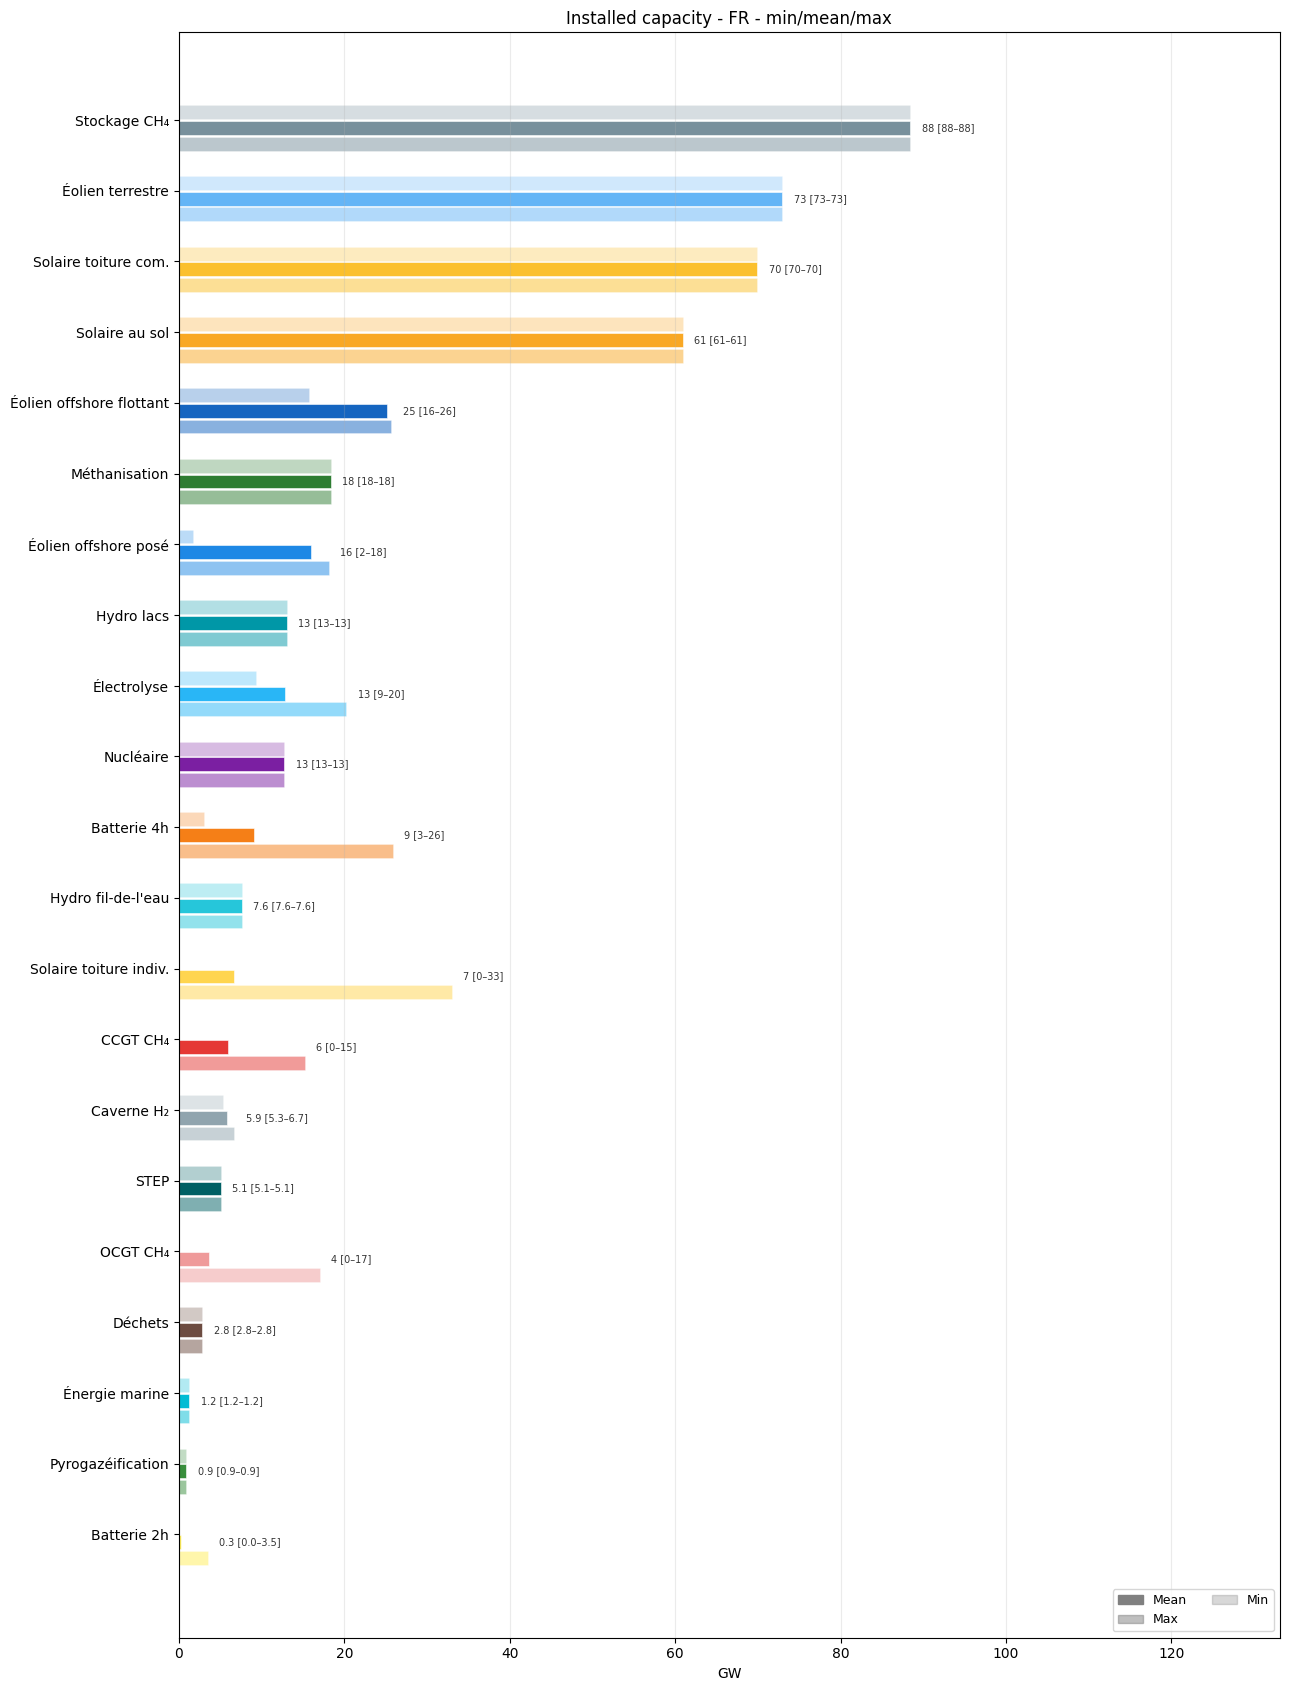

In [74]:
SCENARIOS = { 
    "FR interconnectee": "FR_interconnected",             # e.g. {"FR seule": "FR_alone", "FR interconnectee": "FR_interconnected"}
}
AREA = "FR"

cap_data = {
    label: ub.load_across_years(BATCH_DIR, "installed_power_GW", scenario, YEARS, AREA)
    for label, scenario in SCENARIOS.items()
}
fig = plot_min_mean_max(cap_data, title=f"Installed capacity - {AREA} - min/mean/max", unit="GW")

---
## 1b. Capacite agregee par categorie (batteries, STEP, thermique gaz, solaire...)

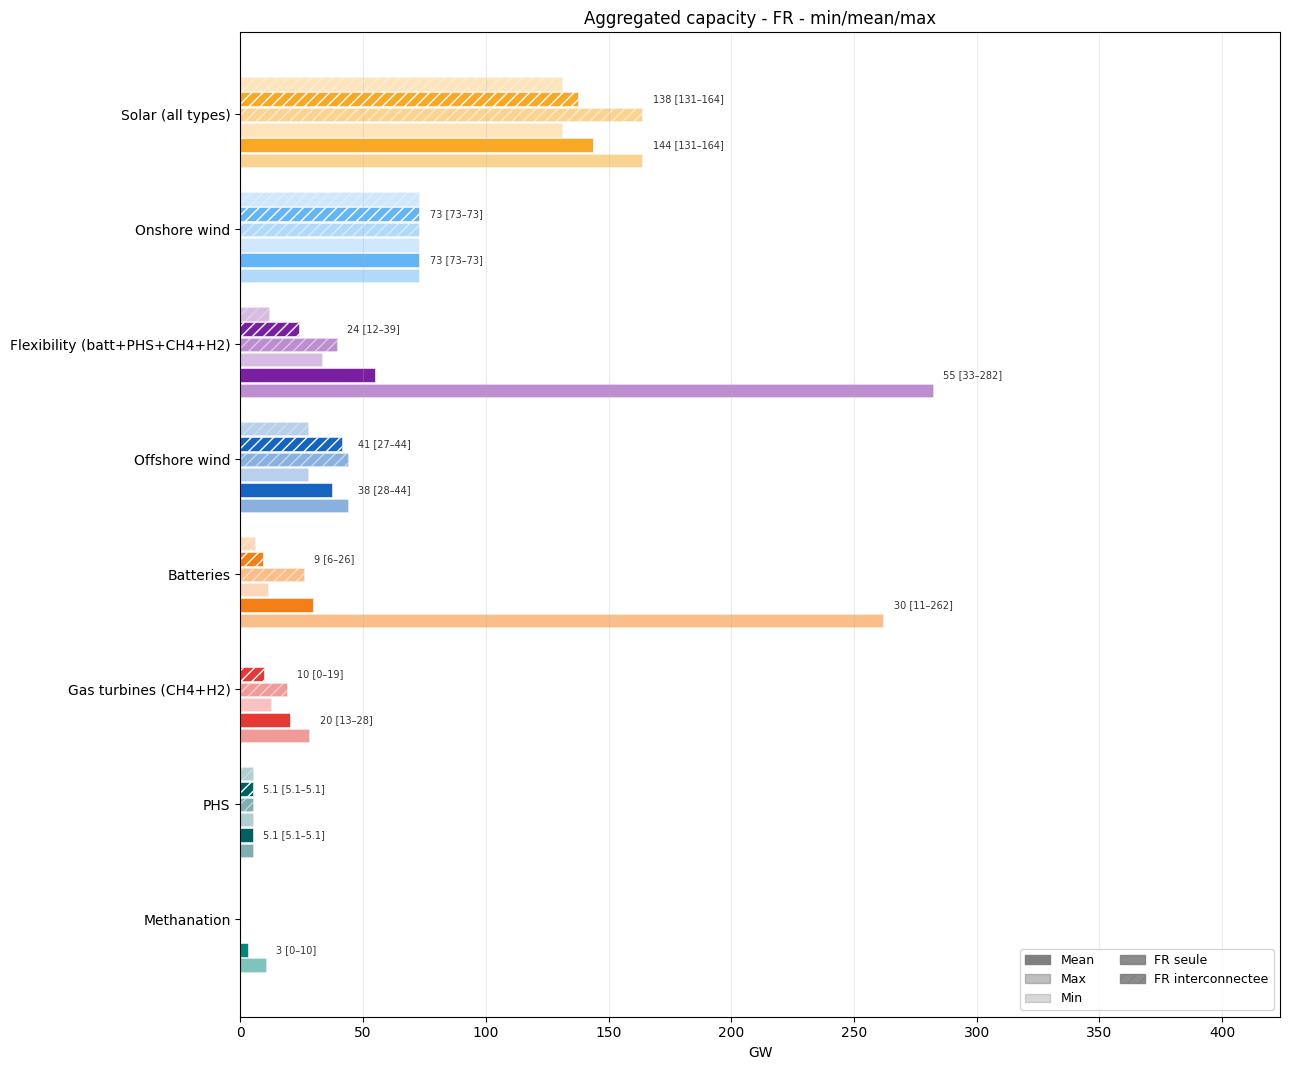

In [31]:
AGG_CAP = {
    "Batteries": ["battery_1h", "battery_2h", "battery_4h", "battery_8h"],
    "PHS": ["phs"],
    "Gas turbines (CH4+H2)": ["ch4_ocgt", "ch4_ccgt", "h2_ccgt"],
    "Methanation": ["methanation"],
    "Solar (all types)": ["pv_ground", "pv_roof_com", "pv_roof_indiv"],
    "Offshore wind": ["offshore_ground", "offshore_float"],
    "Onshore wind": ["onshore"],
    "Flexibility (batt+PHS+CH4+H2)": ["battery_1h", "battery_2h", "battery_4h", "battery_8h",
                                       "phs", "ch4_ocgt", "ch4_ccgt", "h2_ccgt"],
}

cap_agg_data = {label: ub.aggregate_df(df, AGG_CAP) for label, df in cap_data.items() if not df.empty}
fig = plot_min_mean_max(cap_agg_data, title=f"Aggregated capacity - {AREA} - min/mean/max",
                        unit="GW", min_val=0.01, exclude=set(), tech_colors=CATEGORY_COLORS)

---
## 2. Production par technologie : min / moyenne / max

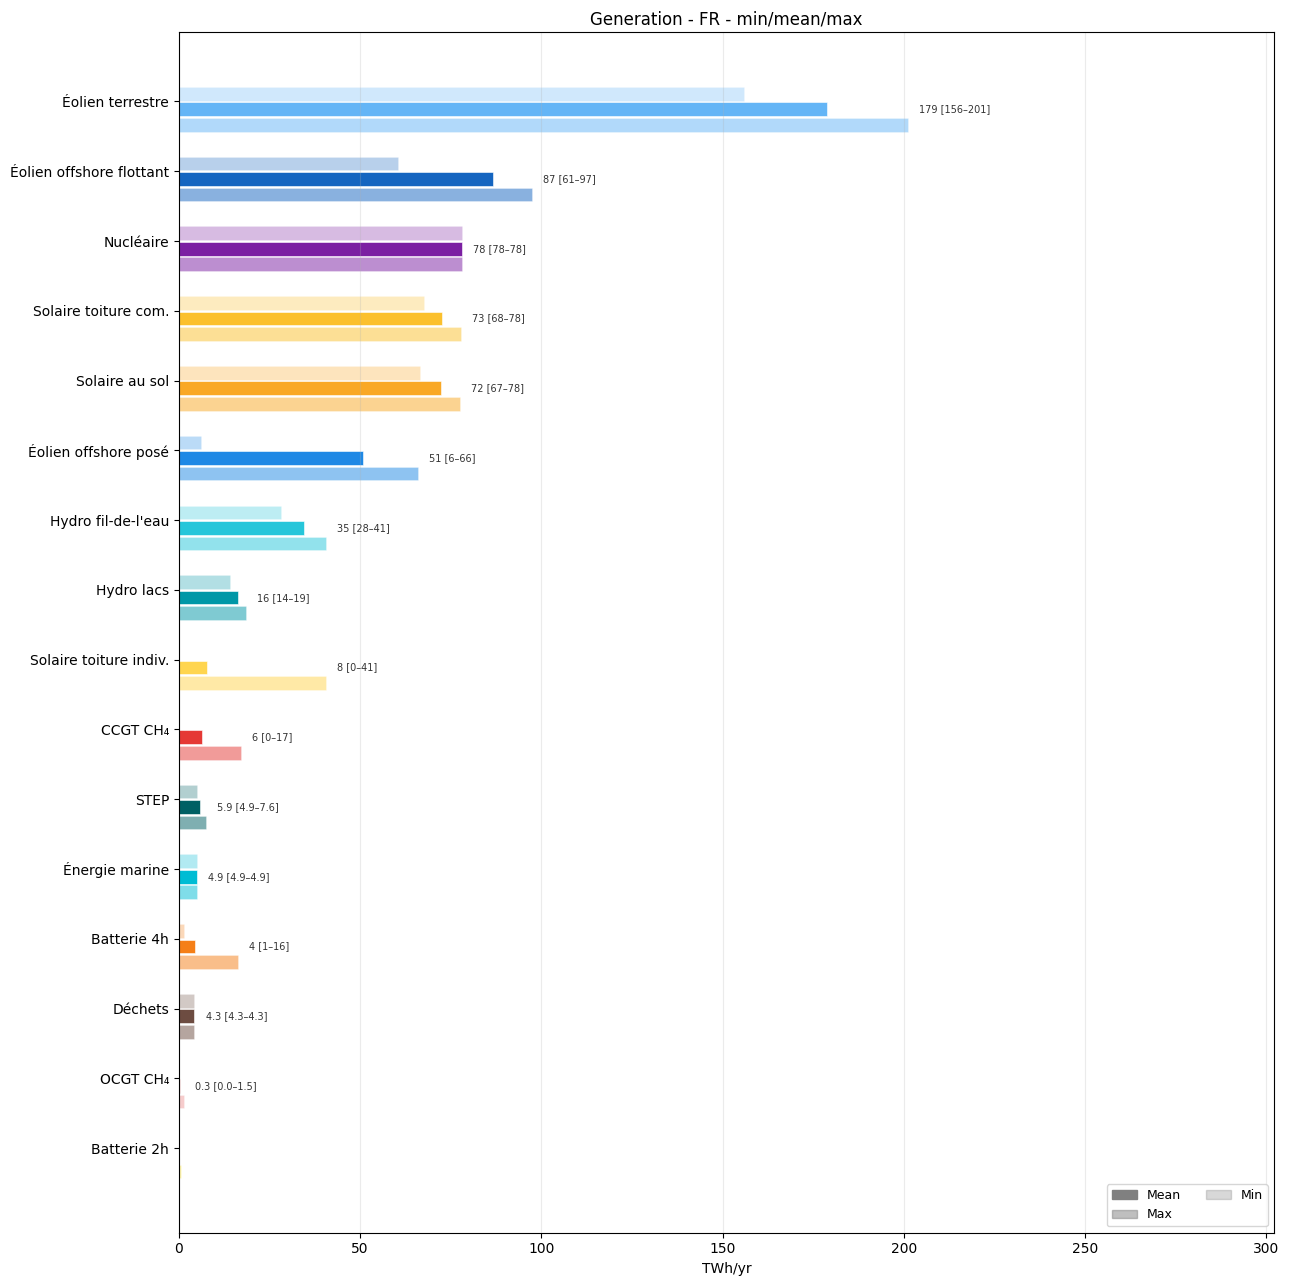

In [76]:
gene_data = {
    label: ub.load_across_years(BATCH_DIR, "generation_per_tech_TWh", scenario, YEARS, AREA)
    for label, scenario in SCENARIOS.items()
}
GENE_EXCLUDE = TECH_EXCLUDE_DEFAULT | {
    "ch4_reservoir", "methanization", "electrolysis",
    "h2_saltcavern", "pyrogazification", "methanation", "biogas_import",
}
fig = plot_min_mean_max(gene_data, title=f"Generation - {AREA} - min/mean/max", unit="TWh/yr",
                        min_val=0.05, exclude=GENE_EXCLUDE)

---
## 3. Cout annualise par vecteur (elec / CH4 / H2)

Cout attribue a `AREA` (CAPEX + CAPEX stockage + O&M alloue proportionnellement a sa part d'investissement), agrege par vecteur, min/moyenne/max sur les annees climatiques.

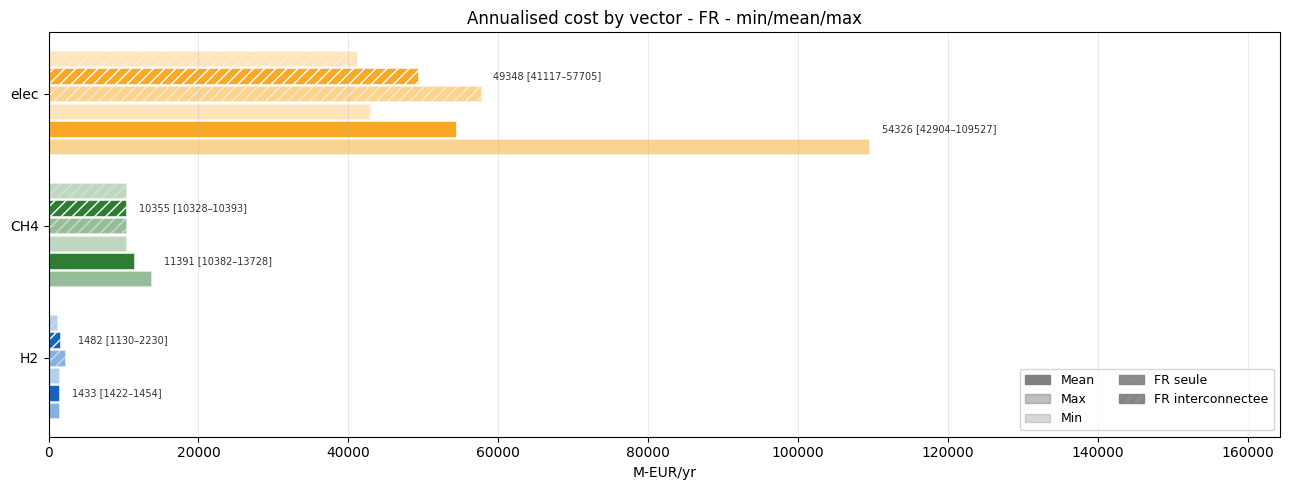

In [33]:
cost_vector_data = {
    label: ub.load_area_cost_by_vector(BATCH_DIR, scenario, YEARS, AREA, TECH_VECTOR)
    for label, scenario in SCENARIOS.items()
}
fig = plot_min_mean_max(cost_vector_data, title=f"Annualised cost by vector - {AREA} - min/mean/max",
                        unit="M-EUR/yr", min_val=1, exclude=set(), tech_colors=CATEGORY_COLORS)

---
## 3b. Cout du secteur electrique par categorie de technologie

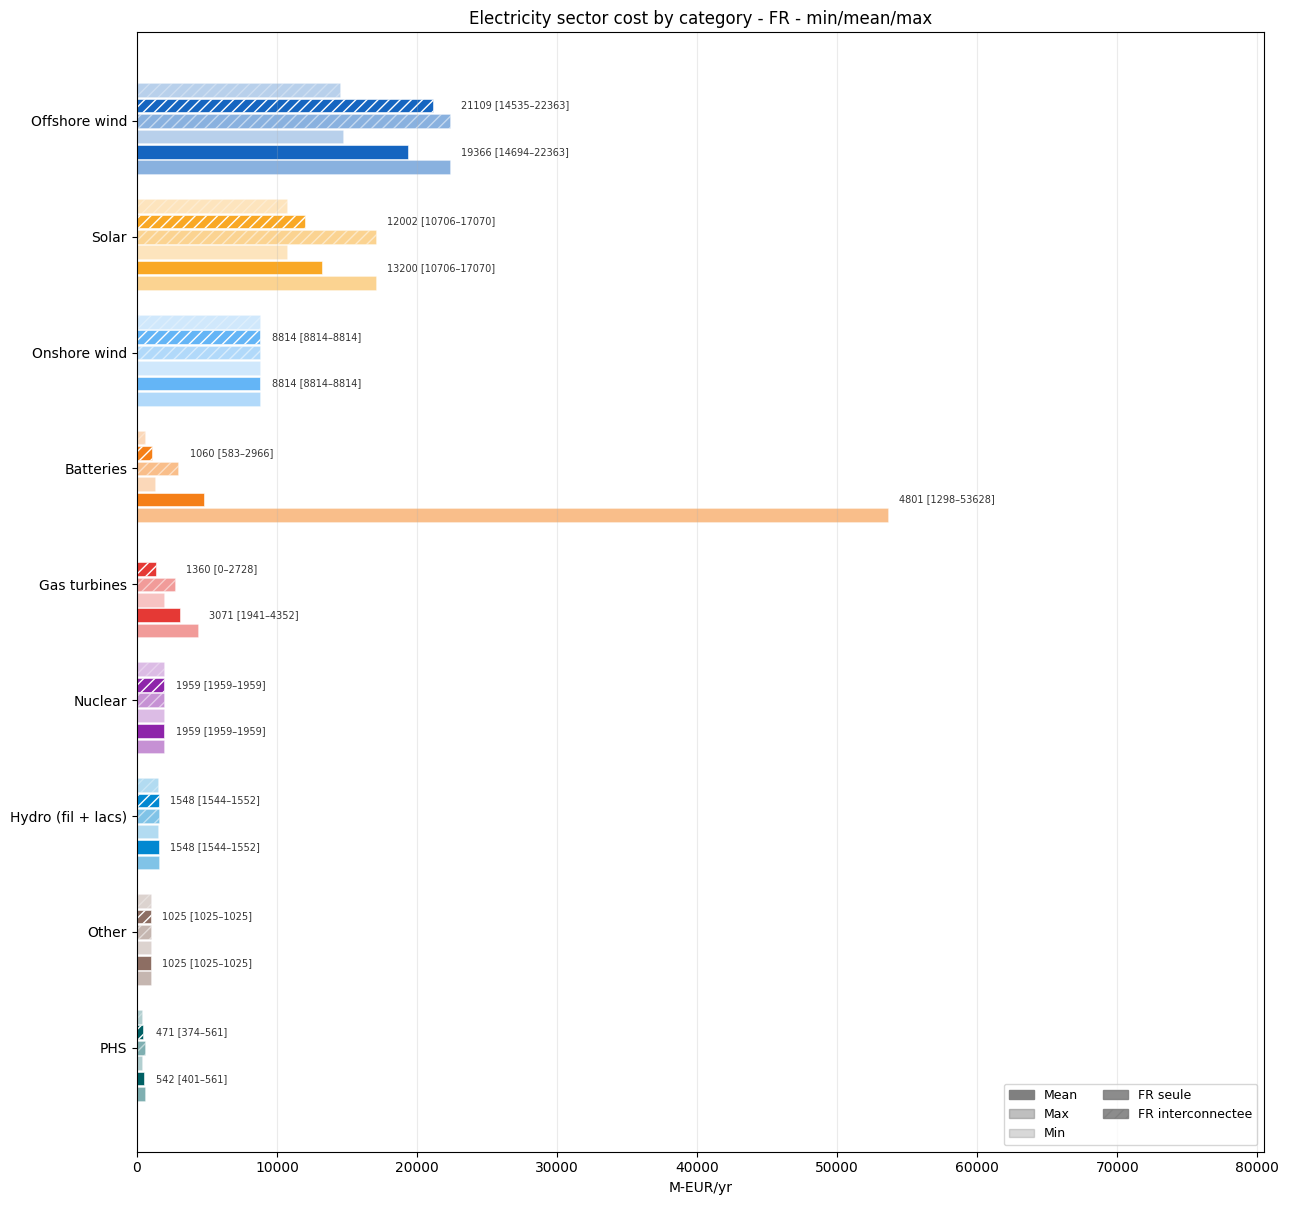

In [34]:
ELEC_COST_GROUPS = {
    "Batteries": ["battery_1h", "battery_2h", "battery_4h", "battery_8h"],
    "Gas turbines": ["ch4_ocgt", "ch4_ccgt", "h2_ccgt"],
    "Solar": ["pv_ground", "pv_roof_com", "pv_roof_indiv"],
    "Hydro": ["river", "lake"],
    "Other": ["waste", "marine", "biomass_coge", "geothermal_coge", "ocgt_coge"],
    "Nuclear": ["nuclear"],
    "Onshore wind": ["onshore"],
    "Offshore wind": ["offshore_float", "offshore_ground"],
    "PHS": ["phs"],
}

cost_group_data = {
    label: ub.build_area_cost_by_group(BATCH_DIR, scenario, YEARS, AREA, ELEC_COST_GROUPS)
    for label, scenario in SCENARIOS.items()
}
fig = plot_min_mean_max(cost_group_data, title=f"Electricity sector cost by category - {AREA} - min/mean/max",
                        unit="M-EUR/yr", min_val=1, exclude=set(), tech_colors=CATEGORY_COLORS)

---
## 4. Flux d'energie par vecteur

Offre <-  | -> demande. Deux vues : (4a) moyenne sur toutes les annees climatiques de `YEARS`, (4b) une annee precise au choix - un diagramme par scenario dans les deux cas.

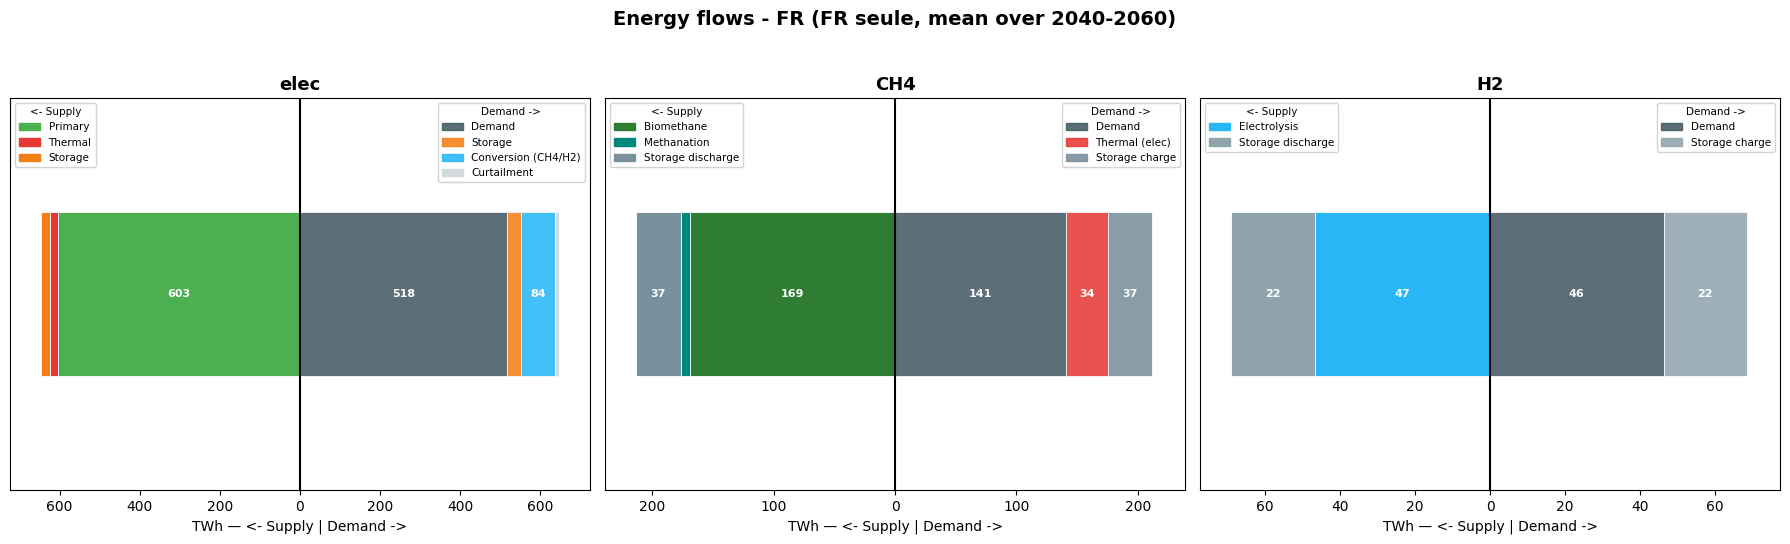

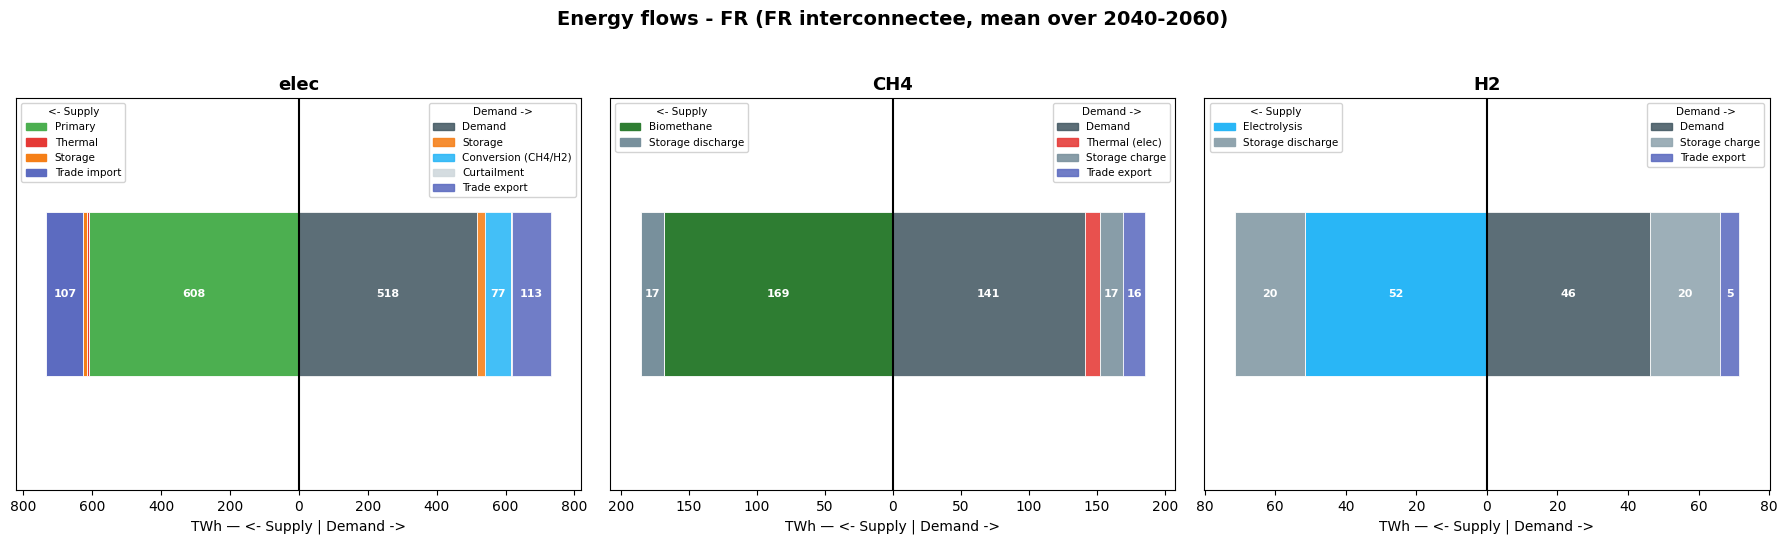

In [35]:
# Groupings for the flow diagram - which techs count as "primary", "storage", etc. per vector.
FLOW_SUPPLY_GROUPS = {
    "elec": [("Primary", ["offshore_float", "offshore_ground", "onshore", "pv_ground", "pv_roof_com",
                          "pv_roof_indiv", "river", "lake", "nuclear", "waste", "marine",
                          "biomass_coge", "geothermal_coge", "ocgt_coge"], "#4CAF50"),
             ("Thermal", ["ch4_ccgt", "ch4_ocgt", "h2_ccgt"], "#E53935"),
             ("Storage", ["phs", "battery_1h", "battery_2h", "battery_4h", "battery_8h"], "#F57F17"),
             ("Trade import", ["elec_trade_imports"], "#5C6BC0")],
    "CH4": [("Biomethane", ["methanization", "pyrogazification"], "#2E7D32"),
            ("Biogas import", ["biogas_import"], "#81C784"),
            ("Methanation", ["methanation"], "#00897B"),
            ("Storage discharge", ["ch4_reservoir"], "#78909C"),
            ("Trade import", ["CH4_trade_imports"], "#5C6BC0")],
    "H2": [("Electrolysis", ["electrolysis"], "#29B6F6"),
           ("Storage discharge", ["h2_saltcavern"], "#90A4AE"),
           ("H2 import", ["H2_import"], "#0288D1"),
           ("Trade import", ["H2_trade_imports"], "#5C6BC0")],
}
FLOW_USAGE_GROUPS = {
    "elec": [("Demand", ["demand"], "#455A64"),
             ("Storage", ["phs_input", "battery_1h_input", "battery_2h_input",
                         "battery_4h_input", "battery_8h_input"], "#F57F17"),
             ("Conversion (CH4/H2)", ["electrolysis_input", "methanation_input"], "#29B6F6"),
             ("Curtailment", ["curtailment"], "#CFD8DC"),
             ("Trade export", ["elec_trade_exports"], "#5C6BC0")],
    "CH4": [("Demand", ["demand"], "#455A64"),
            ("Thermal (elec)", ["ch4_ocgt_input", "ch4_ccgt_input", "ocgt_coge_input"], "#E53935"),
            ("Storage charge", ["ch4_reservoir_input"], "#78909C"),
            ("Trade export", ["CH4_trade_exports"], "#5C6BC0")],
    "H2": [("Demand", ["demand"], "#455A64"),
           ("H2 turbine (elec)", ["h2_ccgt_input"], "#FF6F00"),
           ("Storage charge", ["h2_saltcavern_input"], "#90A4AE"),
           ("Trade export", ["H2_trade_exports"], "#5C6BC0")],
}


def _load_flow_group_values(scenario, year, area):
    """Return (supply_vals, usage_vals): dict {vec: {group_name: value_TWh}} for one (scenario, year)."""
    supply_vals, usage_vals = {}, {}
    d = ub.run_dir(BATCH_DIR, year, scenario)
    for vec in ("elec", "CH4", "H2"):
        supply_raw = ub.get_area_series(d / f"balance_{vec}_supply_TWh.csv", area)
        usage_raw = ub.get_area_series(d / f"balance_{vec}_usage_TWh.csv", area)
        supply_raw = supply_raw.apply(pd.to_numeric, errors="coerce").fillna(0) if supply_raw is not None else pd.Series(dtype=float)
        usage_raw = usage_raw.apply(pd.to_numeric, errors="coerce").fillna(0) if usage_raw is not None else pd.Series(dtype=float)
        supply_vals[vec] = {n: sum(float(supply_raw.get(t, 0)) for t in techs) for n, techs, c in FLOW_SUPPLY_GROUPS[vec]}
        usage_vals[vec] = {n: sum(float(usage_raw.get(t, 0)) for t in techs) for n, techs, c in FLOW_USAGE_GROUPS[vec]}
    return supply_vals, usage_vals


def load_flow_year(scenario, year, area=AREA):
    """Flow diagram groups for a single climate year."""
    supply_vals, usage_vals = _load_flow_group_values(scenario, year, area)
    supply_by_vector = {vec: [(n, supply_vals[vec].get(n, 0), c) for n, techs, c in FLOW_SUPPLY_GROUPS[vec]] for vec in supply_vals}
    usage_by_vector = {vec: [(n, usage_vals[vec].get(n, 0), c) for n, techs, c in FLOW_USAGE_GROUPS[vec]] for vec in usage_vals}
    return supply_by_vector, usage_by_vector


def load_flow_average(scenario, years, area=AREA):
    """Flow diagram groups averaged across every climate year in `years`."""
    totals_supply, totals_usage, n = {}, {}, 0
    for year in years:
        s, u = _load_flow_group_values(scenario, year, area)
        n += 1
        for vec in s:
            for name, val in s[vec].items():
                totals_supply.setdefault(vec, {}).setdefault(name, 0.0)
                totals_supply[vec][name] += val
            for name, val in u[vec].items():
                totals_usage.setdefault(vec, {}).setdefault(name, 0.0)
                totals_usage[vec][name] += val
    n = max(n, 1)
    supply_by_vector = {vec: [(n2, totals_supply.get(vec, {}).get(n2, 0) / n, c) for n2, techs, c in FLOW_SUPPLY_GROUPS[vec]] for vec in FLOW_SUPPLY_GROUPS}
    usage_by_vector = {vec: [(n2, totals_usage.get(vec, {}).get(n2, 0) / n, c) for n2, techs, c in FLOW_USAGE_GROUPS[vec]] for vec in FLOW_USAGE_GROUPS}
    return supply_by_vector, usage_by_vector


# ---- 4a. Average across all climate years, one diagram per scenario -------------------
for label, scenario in SCENARIOS.items():
    supply_by_vector, usage_by_vector = load_flow_average(scenario, YEARS, AREA)
    fig = plot_energy_flows(supply_by_vector, usage_by_vector,
                            title=f"Energy flows - {AREA} ({label}, mean over {YEARS[0]}-{YEARS[-1]})")

### 4b. Une annee climatique precise, un diagramme par scenario

Change `FLOW_YEAR` ci-dessous pour inspecter une autre annee.

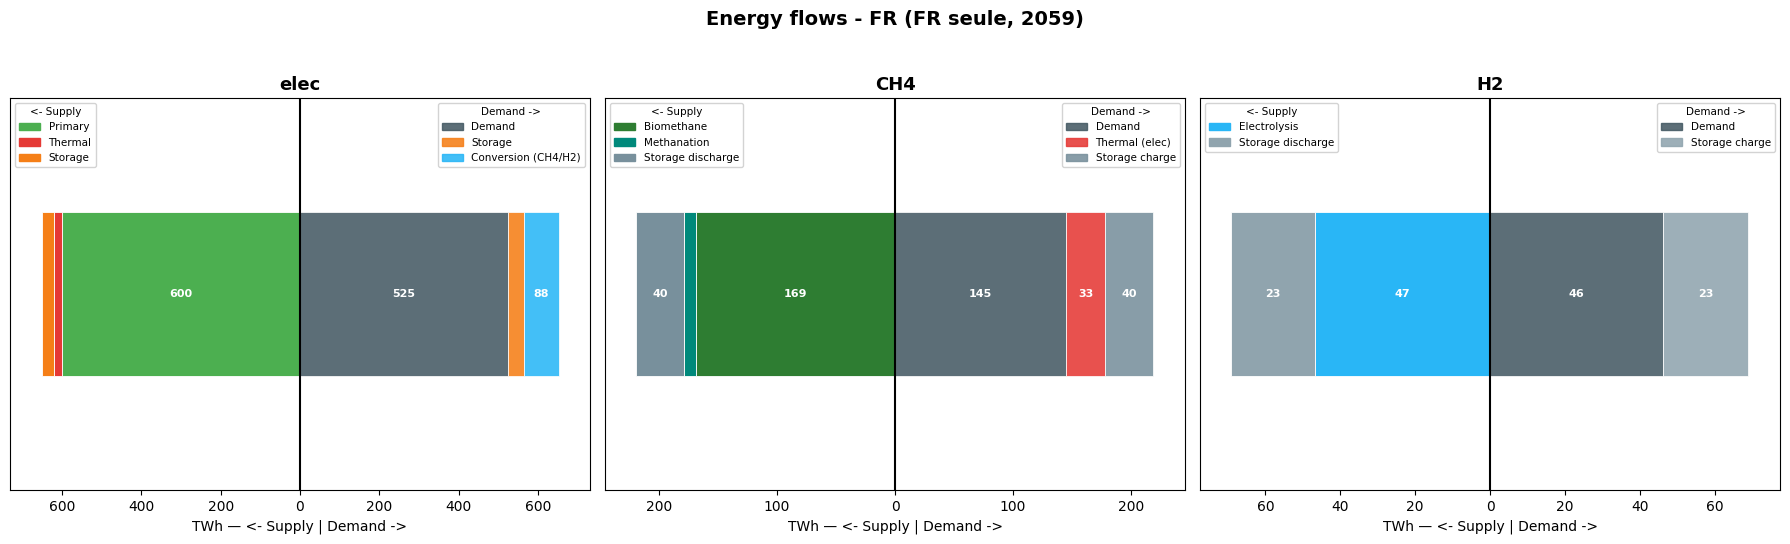

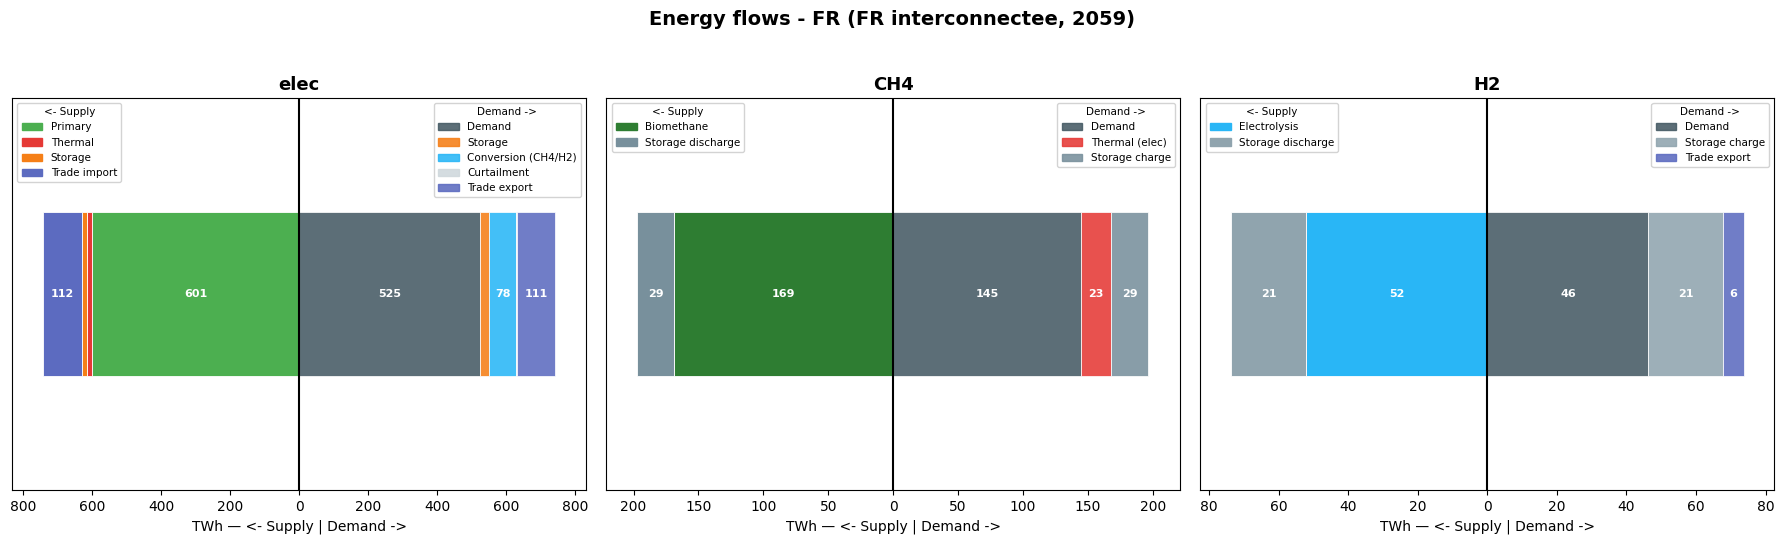

In [36]:
FLOW_YEAR = 2059  # <- change to any year in YEARS

for label, scenario in SCENARIOS.items():
    supply_by_vector, usage_by_vector = load_flow_year(scenario, FLOW_YEAR, AREA)
    fig = plot_energy_flows(supply_by_vector, usage_by_vector,
                            title=f"Energy flows - {AREA} ({label}, {FLOW_YEAR})")

---
## 5. LCOE par vecteur

LCOE = (CAPEX annualise + O&M alloue) / production, par vecteur, moyenne +/- min/max sur les annees climatiques.

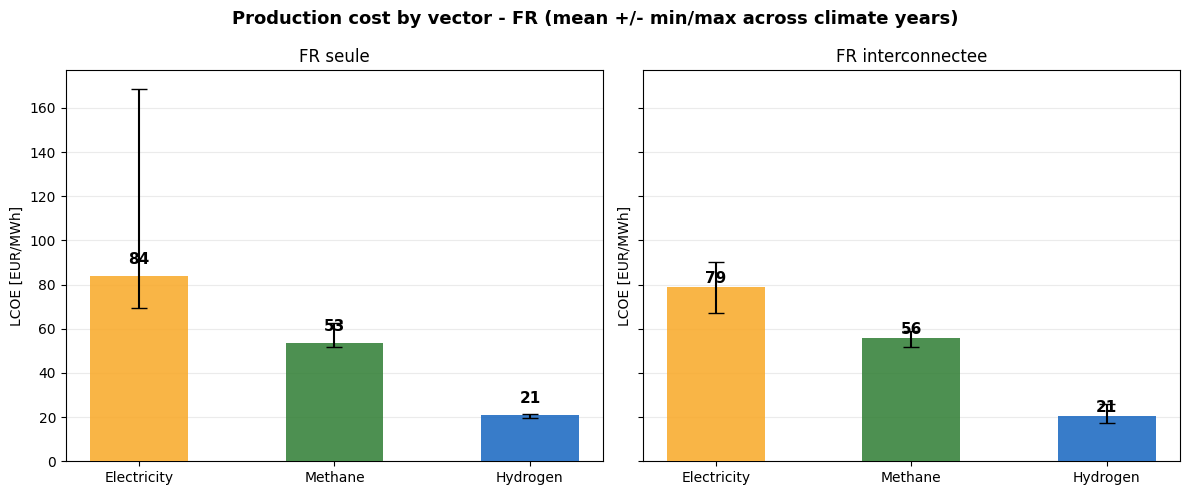

In [37]:
import matplotlib.pyplot as plt

lcoe_results = {
    label: ub.compute_cost_per_production(BATCH_DIR, scenario, YEARS, AREA, TECH_VECTOR)
    for label, scenario in SCENARIOS.items()
}
VEC_NAMES = {"elec": "Electricity", "CH4": "Methane", "H2": "Hydrogen"}
VEC_COLS = {"elec": "#F9A825", "CH4": "#2E7D32", "H2": "#1565C0"}

n_scen = len(lcoe_results)
fig, axes = plt.subplots(1, n_scen, figsize=(6 * n_scen, 5), sharey=True)
if n_scen == 1:
    axes = [axes]

for ax, (label, df) in zip(axes, lcoe_results.items()):
    vecs = [v for v in ["elec", "CH4", "H2"] if f"lcoe_{v}" in df.columns]
    vlbls = [VEC_NAMES[v] for v in vecs]
    vcols = [VEC_COLS[v] for v in vecs]
    means = [df[f"lcoe_{v}"].mean() for v in vecs]
    lo = [df[f"lcoe_{v}"].mean() - df[f"lcoe_{v}"].min() for v in vecs]
    hi = [df[f"lcoe_{v}"].max() - df[f"lcoe_{v}"].mean() for v in vecs]
    bars = ax.bar(vlbls, means, color=vcols, alpha=0.85, width=0.5, zorder=3)
    ax.errorbar(vlbls, means, yerr=[lo, hi], fmt="none", color="black", capsize=6, linewidth=1.5, zorder=4)
    for bar, mean_val in zip(bars, means):
        if not np.isnan(mean_val):
            ax.text(bar.get_x() + bar.get_width() / 2, mean_val + max(hi) * 0.05,
                   f"{mean_val:.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(label, fontsize=12)
    ax.set_ylabel("LCOE [EUR/MWh]")
    ax.grid(axis="y", alpha=0.25, zorder=0)

fig.suptitle(f"Production cost by vector - {AREA} (mean +/- min/max across climate years)",
            fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Evolution capacite / production selon l'annee climatique

Chaque point = une annee climatique (optimisation independante). Montre si les actifs flexibles varient beaucoup d'une annee a l'autre.

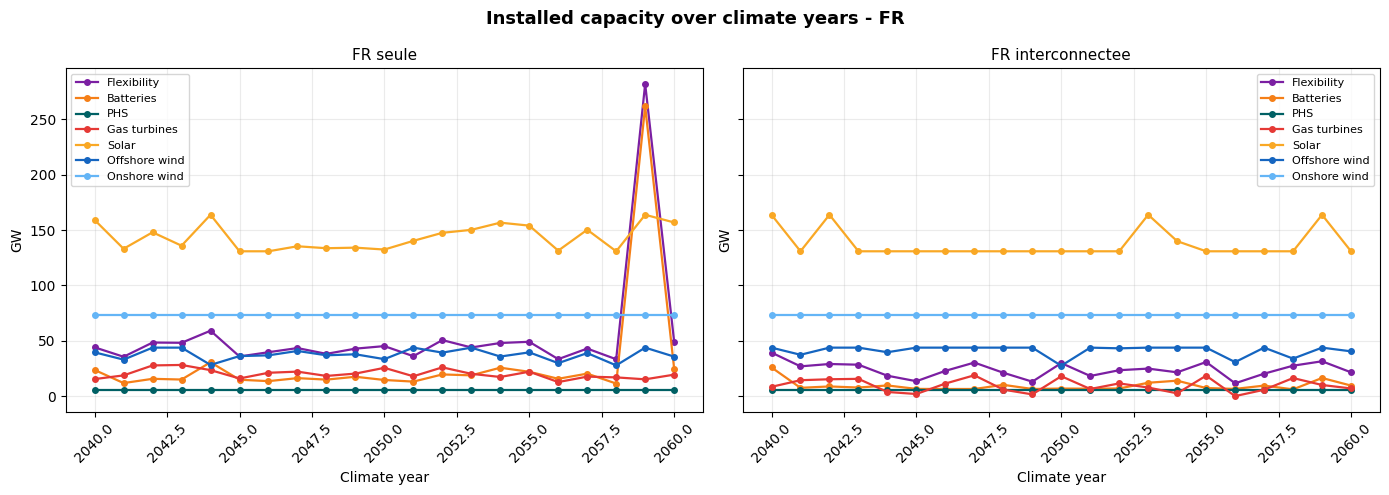

In [38]:
TS_CATEGORIES = {
    "Flexibility": ["battery_1h", "battery_2h", "battery_4h", "battery_8h", "phs", "ch4_ocgt", "ch4_ccgt", "h2_ccgt"],
    "Batteries": ["battery_1h", "battery_2h", "battery_4h", "battery_8h"],
    "PHS": ["phs"],
    "Gas turbines": ["ch4_ocgt", "ch4_ccgt", "h2_ccgt"],
    "Solar": ["pv_ground", "pv_roof_com", "pv_roof_indiv"],
    "Offshore wind": ["offshore_float", "offshore_ground"],
    "Onshore wind": ["onshore"],
}

TS_CATEGORIES_bis = {
    "Flexibility": ["battery_1h", "battery_2h", "battery_4h", "battery_8h", "phs", "ch4_ocgt", "ch4_ccgt", "h2_ccgt"],
    "Batteries": ["battery_1h", "battery_2h", "battery_4h", "battery_8h"],
    "PHS": ["phs"],
    "Gas turbines": ["ch4_ocgt", "ch4_ccgt", "h2_ccgt"]
}

TS_COLORS = {
    "Flexibility": "#7B1FA2", "Batteries": "#F57F17", "PHS": "#006064",
    "Gas turbines": "#E53935", "Solar": "#F9A825", "Offshore wind": "#1565C0", "Onshore wind": "#64B5F6",
}

fig = plot_category_timeseries(cap_data, categories=TS_CATEGORIES, category_colors=TS_COLORS,
                               unit="GW", title=f"Installed capacity over climate years - {AREA}")

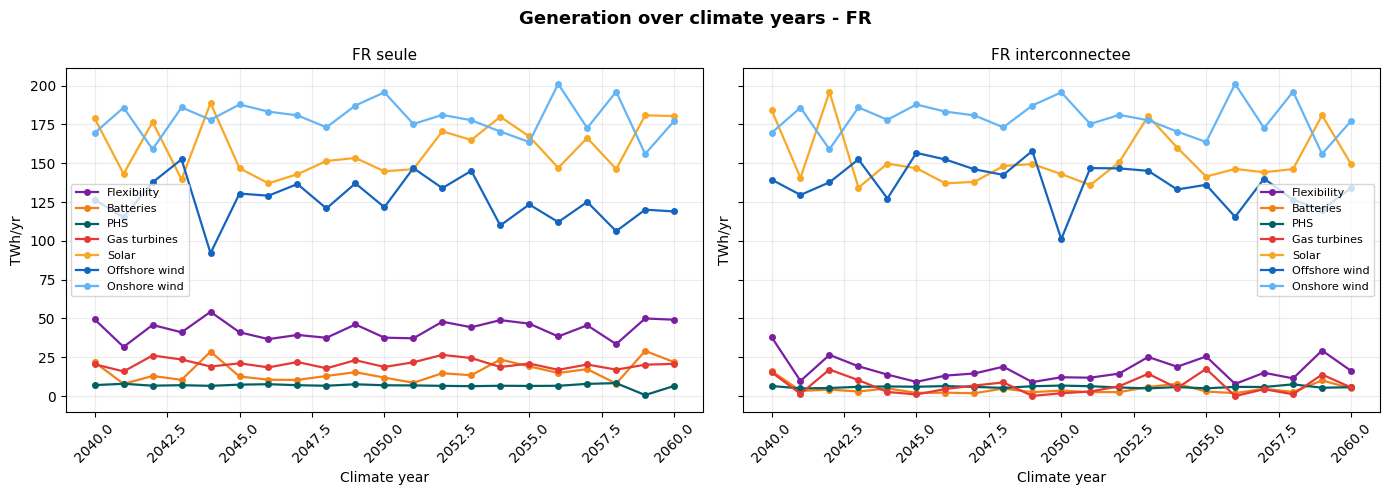

In [39]:
fig = plot_category_timeseries(gene_data, categories=TS_CATEGORIES, category_colors=TS_COLORS,
                               unit="TWh/yr", title=f"Generation over climate years - {AREA}")

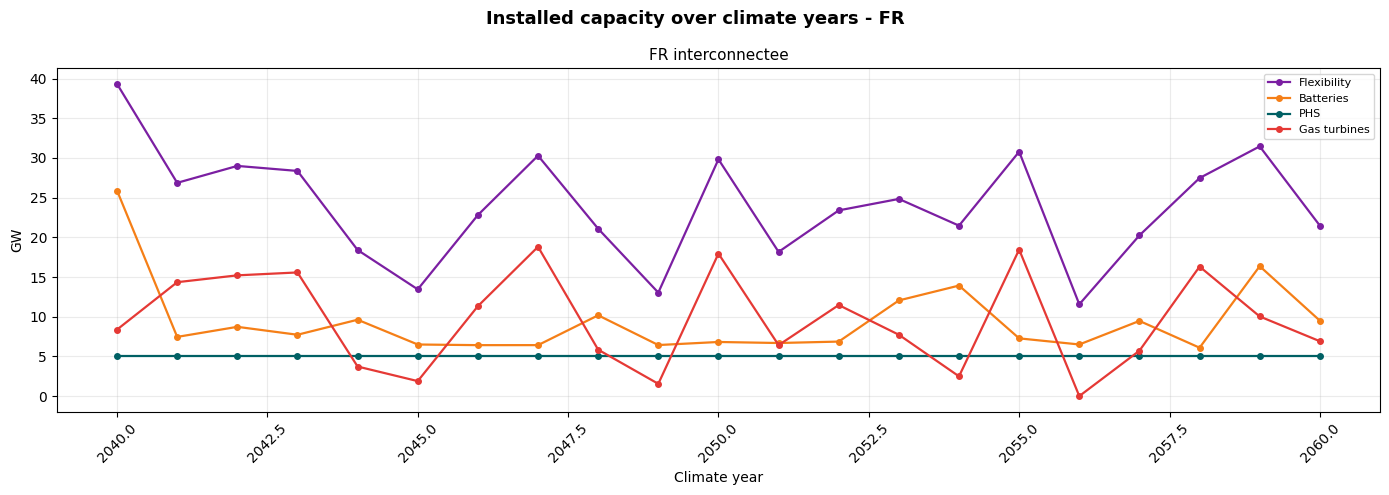

In [75]:
fig = plot_category_timeseries(cap_data, categories=TS_CATEGORIES_bis, category_colors=TS_COLORS,
                               unit="GW", title=f"Installed capacity over climate years - {AREA}")

---
## 7. Lost load par pays

Utilise le premier scenario de `SCENARIOS` (typiquement le scenario interconnecte, seul a avoir plusieurs pays).

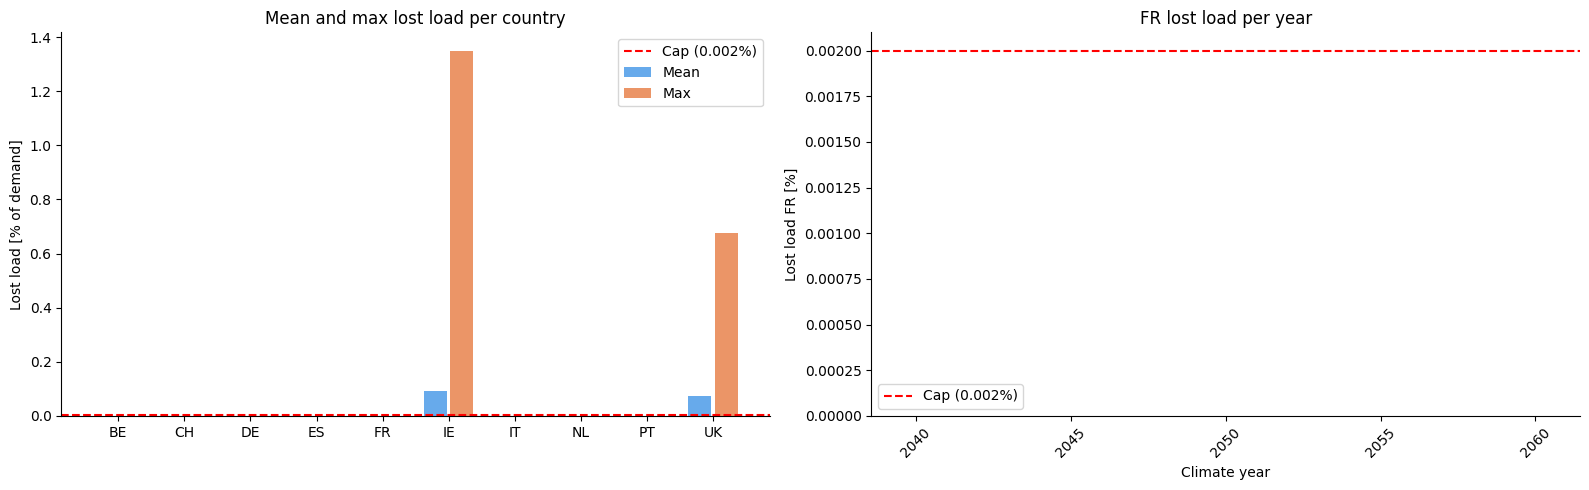

In [65]:
ll_pivot = ub.load_lost_load(BATCH_DIR, "FR_interconnected", YEARS, COUNTRIES)
fig = plot_lost_load(ll_pivot, focus_country= "FR" , lang="EN")

### 7b. Diagnostic : quelles annees/pays, et pourquoi

Pour chaque (annee, pays, scenario) avec de la lost load au-dessus de `LOST_LOAD_THRESHOLD_PCT`, on rapproche la demande residuelle de pointe (`peak_residual_demand_GW`, depuis `residual_load_stats.csv`) de la capacite pilotable installee cette annee-la (`dispatchable_capacity_GW` : nucleaire, charbon, turbines gaz, STEP, batteries, lacs). `margin_GW` = capacite - pointe :
- **marge faible ou negative** -> manque reel de capacite pilotable cette annee (dimensionnement insuffisant).
- **marge confortable malgre la lost load** -> probablement un probleme de timing/dispatch (ex: stockage vide au mauvais moment) plutot qu'un manque de capacite brute - a creuser dans le dispatch horaire de cette semaine precise (voir `notebook_single_run_exploitation.ipynb`).

In [42]:
LOST_LOAD_THRESHOLD_PCT = 0.001  # % of demand - change to be stricter/looser
DISPATCHABLE_TECHS = ["nuclear", "coal", "ch4_ocgt", "ch4_ccgt", "h2_ccgt",
                      "phs", "battery_1h", "battery_2h", "battery_4h", "battery_8h", "lake"]


def diagnose_lost_load(scenario, years, countries, threshold_pct=LOST_LOAD_THRESHOLD_PCT):
    ll_pivot = ub.load_lost_load(BATCH_DIR, scenario, years, countries)  # fraction, not %
    rows = []
    for year in years:
        if year not in ll_pivot.index:
            continue
        for country in countries:
            if country not in ll_pivot.columns:
                continue
            ll_frac = ll_pivot.loc[year, country]
            if pd.isna(ll_frac) or ll_frac * 100 < threshold_pct:
                continue
            cap = ub.get_area_series(ub.run_dir(BATCH_DIR, year, scenario) / "installed_power_GW.csv", country)
            cap = cap.apply(pd.to_numeric, errors="coerce").fillna(0) if cap is not None else pd.Series(dtype=float)
            dispatch_cap = sum(float(cap.get(t, 0)) for t in DISPATCHABLE_TECHS)
            rl_stats = ub.load_residual_load_stats(BATCH_DIR, scenario, [year], country)
            peak_gw = float(rl_stats.loc[year, "peak_gw"]) if not rl_stats.empty and year in rl_stats.index else np.nan
            rows.append({
                "year": year, "country": country,
                "lost_load_%": ll_frac * 100,
                "peak_residual_demand_GW": peak_gw,
                "dispatchable_capacity_GW": dispatch_cap,
                "margin_GW": dispatch_cap - peak_gw if not np.isnan(peak_gw) else np.nan,
            })
    return pd.DataFrame(rows)


lost_load_parts = [diagnose_lost_load(scenario, YEARS, COUNTRIES).assign(scenario=label)
                   for label, scenario in SCENARIOS.items()]
lost_load_parts = [df for df in lost_load_parts if not df.empty]
lost_load_diag = pd.concat(lost_load_parts, ignore_index=True) if lost_load_parts else pd.DataFrame()

if lost_load_diag.empty:
    print(f"No lost load above {LOST_LOAD_THRESHOLD_PCT}% found.")
else:
    display(lost_load_diag.sort_values("lost_load_%", ascending=False))

,year,country,lost_load_%,peak_residual_demand_GW,dispatchable_capacity_GW,margin_GW,scenario
4,2044,IE,1.350183,8.740497,6.991747,-1.748750,FR interconnectee
12,2056,UK,0.676195,99.989510,81.294905,-18.694605,FR interconnectee
3,2044,UK,0.637977,94.931105,78.851724,-16.079380,FR interconnectee
11,2055,IE,0.205298,9.635835,5.493139,-4.142696,FR interconnectee
1,2042,IE,0.114640,8.658229,6.973414,-1.684815,FR interconnectee
2,2043,IE,0.096505,10.442776,9.363115,-1.079661,FR interconnectee
0,2042,UK,0.086457,95.959829,82.147782,-13.812047,FR interconnectee
14,2057,IE,0.069947,8.109628,6.812693,-1.296935,FR interconnectee
16,2060,IE,0.064399,8.638157,4.868740,-3.769417,FR interconnectee
15,2060,UK,0.050888,81.287497,68.592699,-12.694798,FR interconnectee


---
## 8. Ecretement (curtailment) par pays

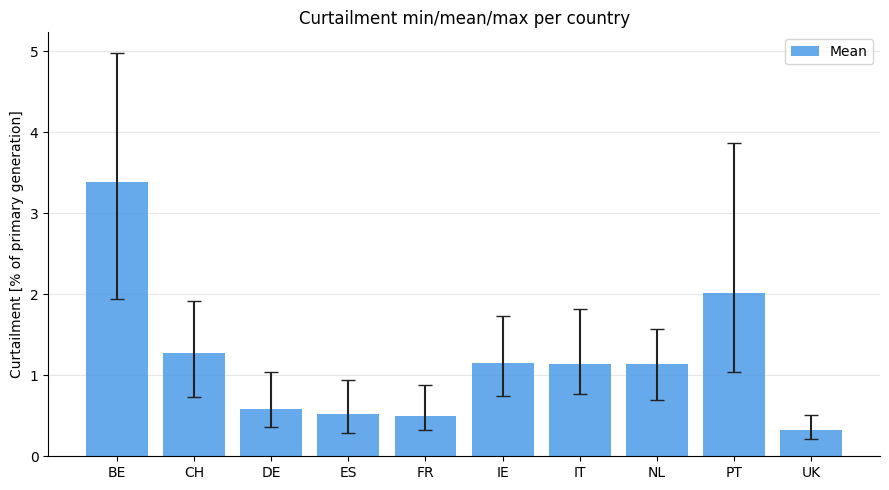

In [43]:
curt_pct, curt_twh = ub.load_curtailment(BATCH_DIR, "FR_interconnected", YEARS, COUNTRIES)
fig = plot_curtailment_stats(curt_pct, lang="EN")

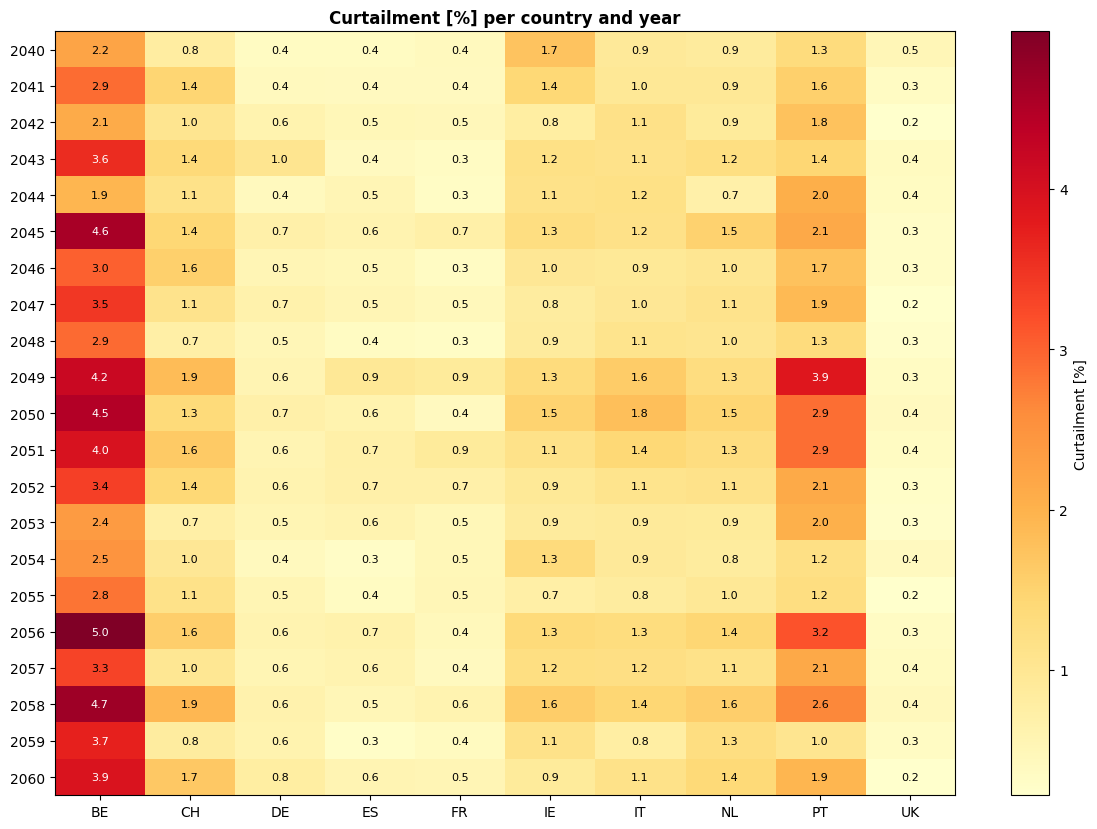

In [44]:
fig = plot_curtailment_heatmap(curt_pct, lang="EN")

---
## 9. Bilan des echanges par pays (elec / CH4+biogaz / H2)

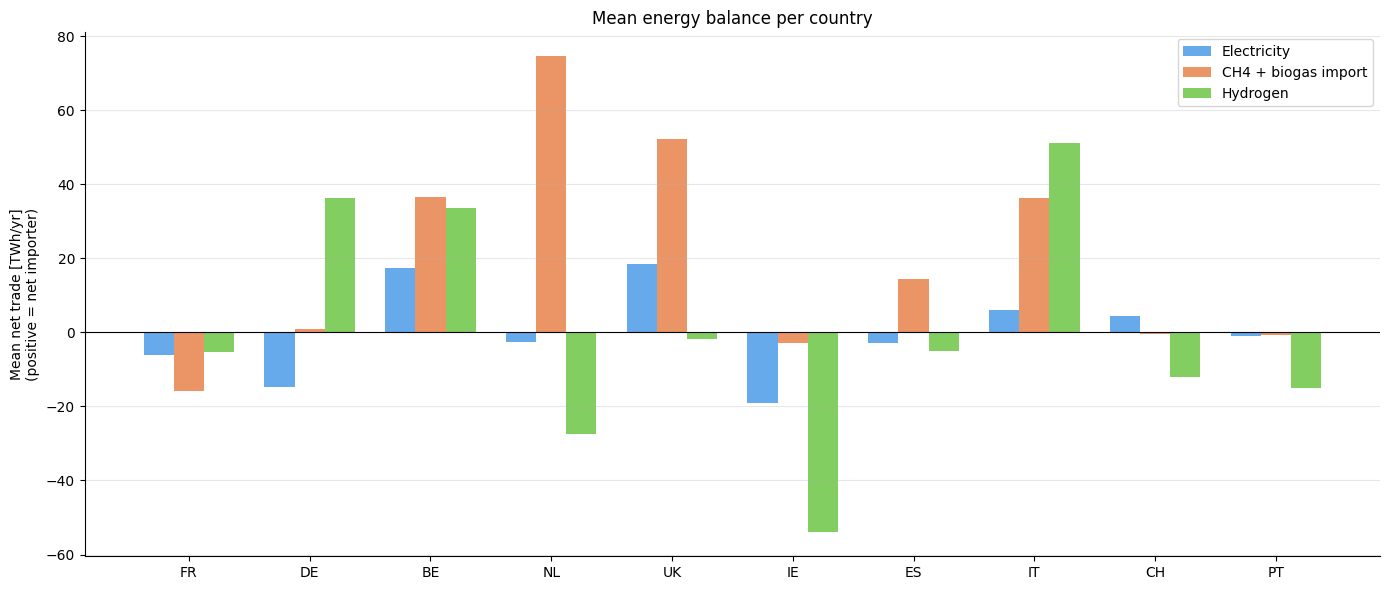

In [45]:
trade_df = ub.load_trade_balance(BATCH_DIR, "FR_interconnected", YEARS, COUNTRIES)
fig = plot_trade_balance(trade_df, COUNTRIES, lang="EN")

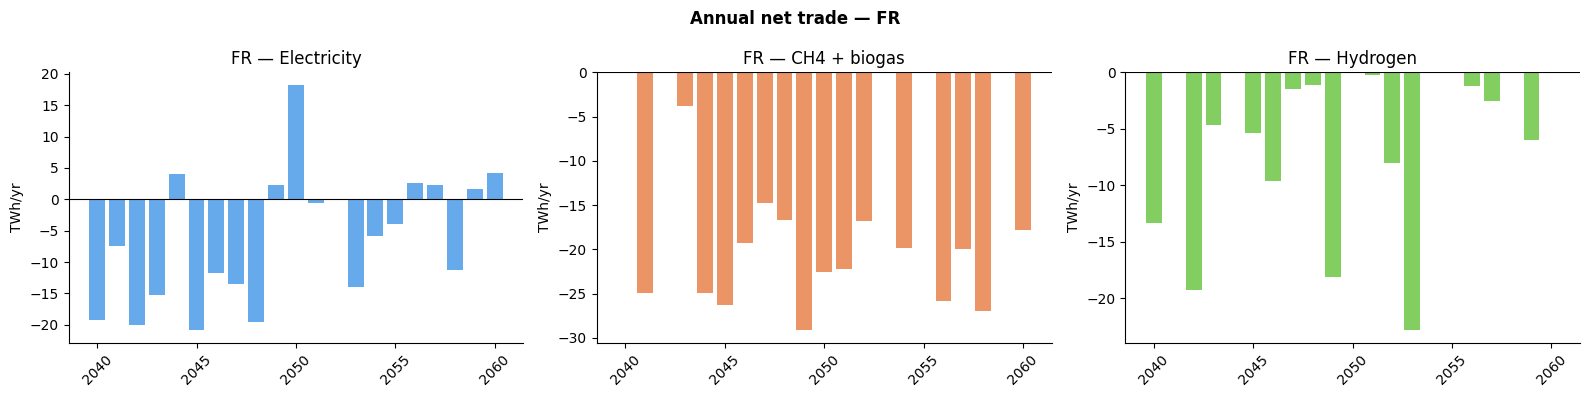

In [46]:
fig = plot_trade_balance_detail(trade_df, AREA, lang="EN")

### 9b. Interconnexions - vue synthetique (import/export)

Une barre par pays partenaire : import (`partenaire -> AREA`) en rouge a gauche, export (`AREA -> partenaire`) en bleu a droite, chacun decompose en a l'arret / partiel / sature. Necessite `interconnection_stats.csv` (ecrit par `save_interconnection_stats` - absent pour un scenario mono-pays, sans interconnexion). Deux vues, un diagramme par scenario (ceux qui ont des interconnexions) dans les deux cas : (9b) moyenne sur toutes les annees de `YEARS`, (9c) une annee precise au choix (`FLOW_YEAR`, meme variable que la section 4b).

[FR seule] no interconnection data (mono-country scenario?) - skipped


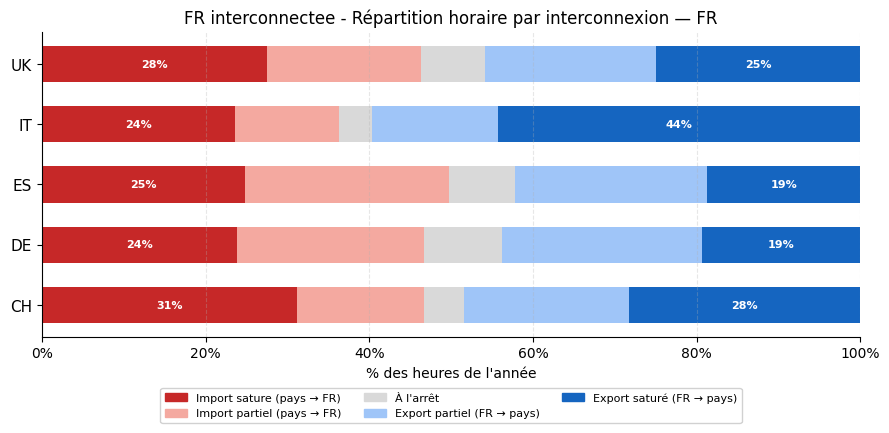

In [47]:
# ---- 9b. Average across all climate years, one diagram per scenario with interconnections
for label, scenario in SCENARIOS.items():
    interco_stats = ub.load_interconnection_stats(BATCH_DIR, scenario, YEARS)
    if interco_stats.empty:
        print(f"[{label}] no interconnection data (mono-country scenario?) - skipped")
        continue
    fig, ax = plot_interconnection_diverging(interco_stats, area=AREA, lang="FR")
    ax.set_title(f"{label} - " + ax.get_title())

[FR seule] no interconnection data for 2059 (mono-country scenario?) - skipped


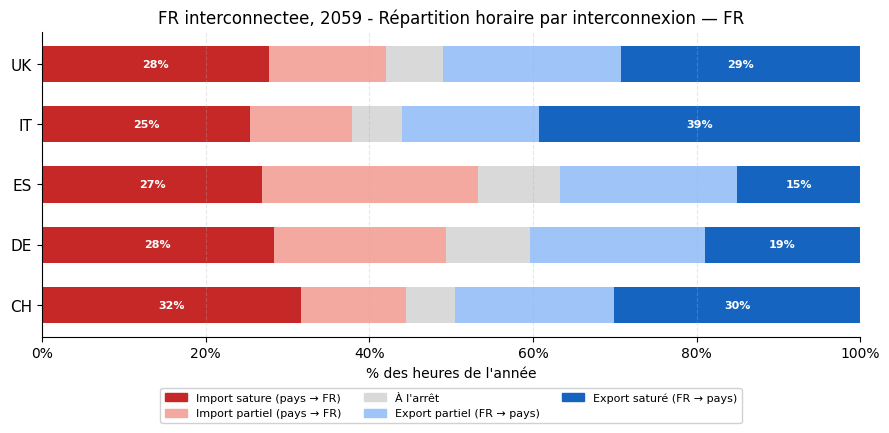

In [48]:
# ---- 9c. A single chosen year (FLOW_YEAR, from section 4b), one diagram per scenario ----
for label, scenario in SCENARIOS.items():
    interco_stats_year = ub.load_interconnection_stats(BATCH_DIR, scenario, [FLOW_YEAR])
    if interco_stats_year.empty:
        print(f"[{label}] no interconnection data for {FLOW_YEAR} (mono-country scenario?) - skipped")
        continue
    fig, ax = plot_interconnection_diverging(interco_stats_year, area=AREA, lang="FR")
    ax.set_title(f"{label}, {FLOW_YEAR} - " + ax.get_title())

---
## 10. Demande residuelle vs flexibilite, dans le temps

Necessite `residual_load_stats.csv` (ecrit par `save_residual_load`, appele par `run_batch.py` et `example.py`).

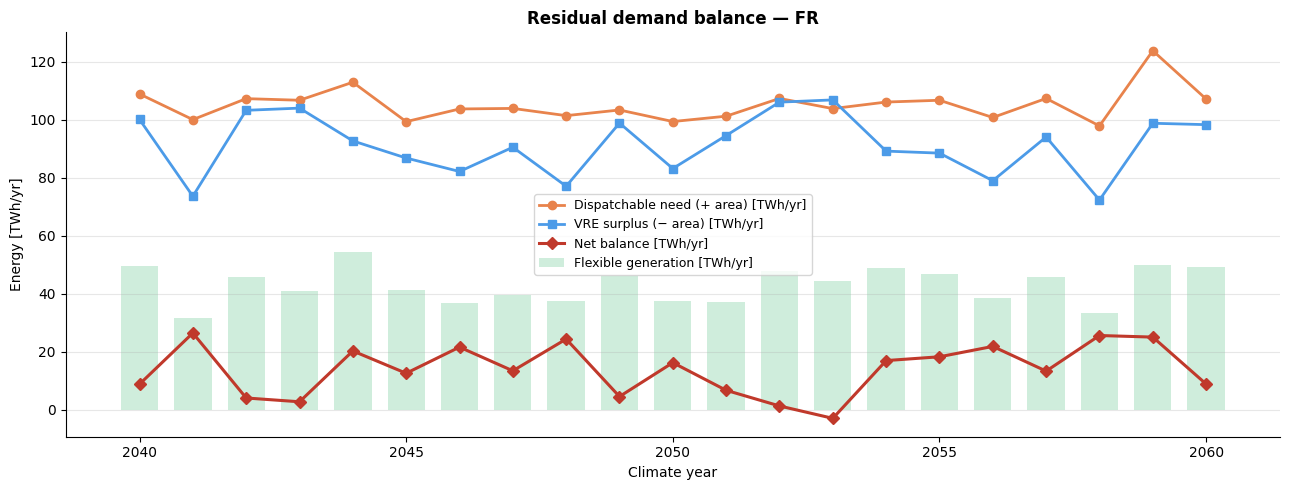

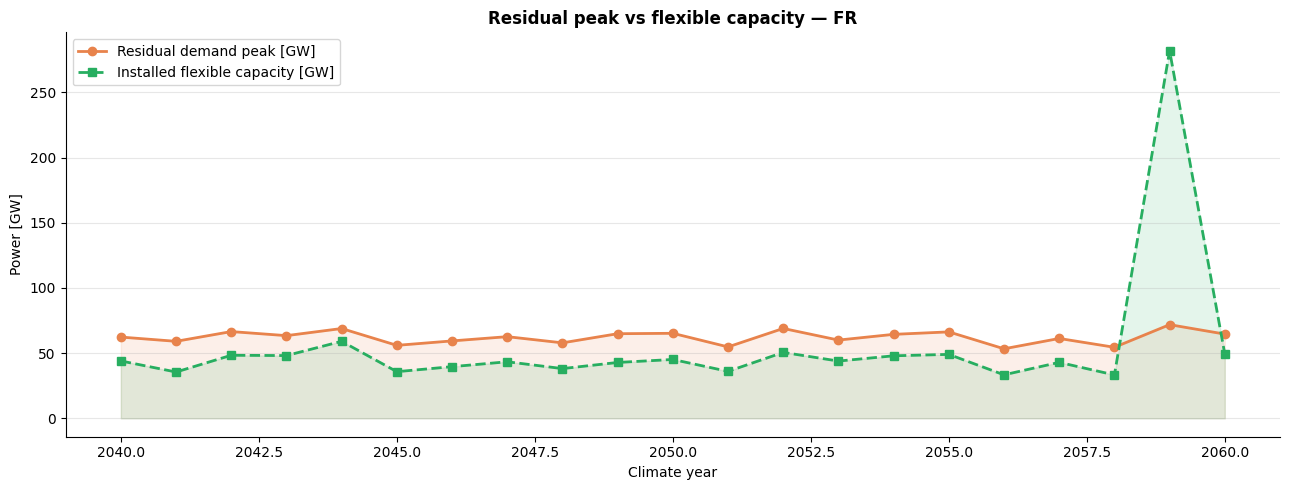

In [49]:
FLEX_TECHS = ["phs", "battery_1h", "battery_2h", "battery_4h", "battery_8h", "ch4_ocgt", "ch4_ccgt", "h2_ccgt"]

residual_stats = ub.load_residual_load_stats(BATCH_DIR, first_scenario, YEARS, AREA)
flex_gen = gene_data[first_label][[c for c in FLEX_TECHS if c in gene_data[first_label].columns]].sum(axis=1)
flex_cap = cap_data[first_label][[c for c in FLEX_TECHS if c in cap_data[first_label].columns]].sum(axis=1)

fig1, fig2 = plot_residual_vs_flexibility(residual_stats, flex_gen, flex_cap, area=AREA, lang="EN")

---
## 11. Duals - contraintes de capacite maximale

Moyenne inter-annuelle du dual (M-EUR/GW/an) par techno et par pays, pour les groupes prod/conv/str. Necessite les fichiers `duals/dual_max_capacity_*.csv` (ecrits par `save_duals`).

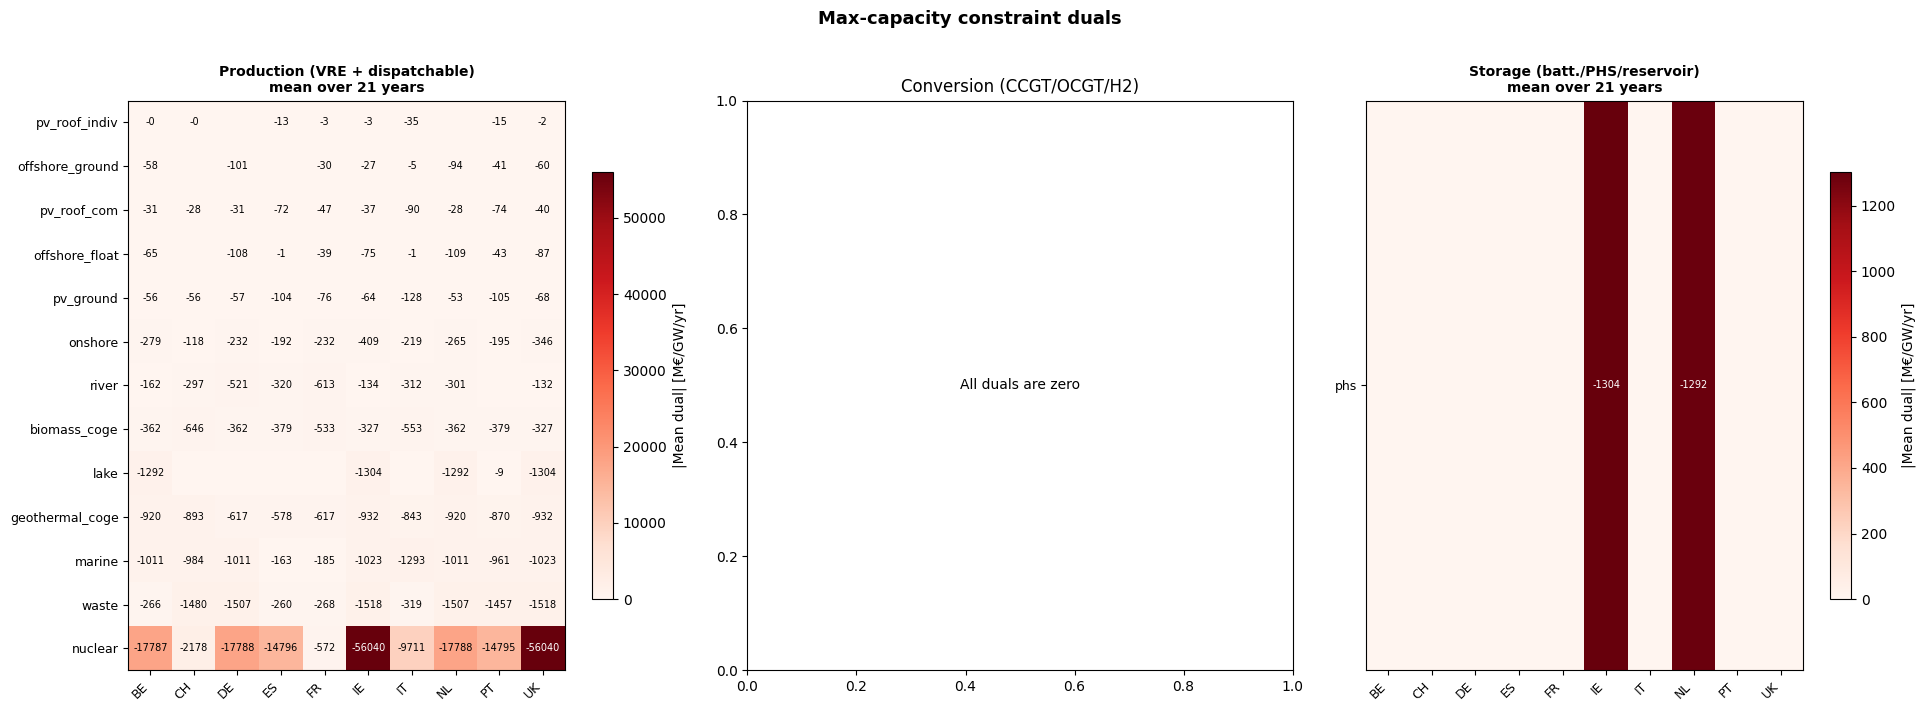

In [50]:
GROUPS = {"prod": "Production (VRE + dispatchable)", "conv": "Conversion (CCGT/OCGT/H2)", "str": "Storage (batt./PHS/reservoir)"}
duals_by_group = {g: ub.load_capacity_duals(BATCH_DIR, "FR_interconnected", YEARS, g) for g in GROUPS}
fig = plot_capacity_duals_heatmap(duals_by_group, group_labels=GROUPS, lang="EN")

---
## 12. Duals - contraintes annuelles

Necessite les fichiers `duals/dual_annual_*.csv` et `duals/dual_methanation_CO2.csv`.

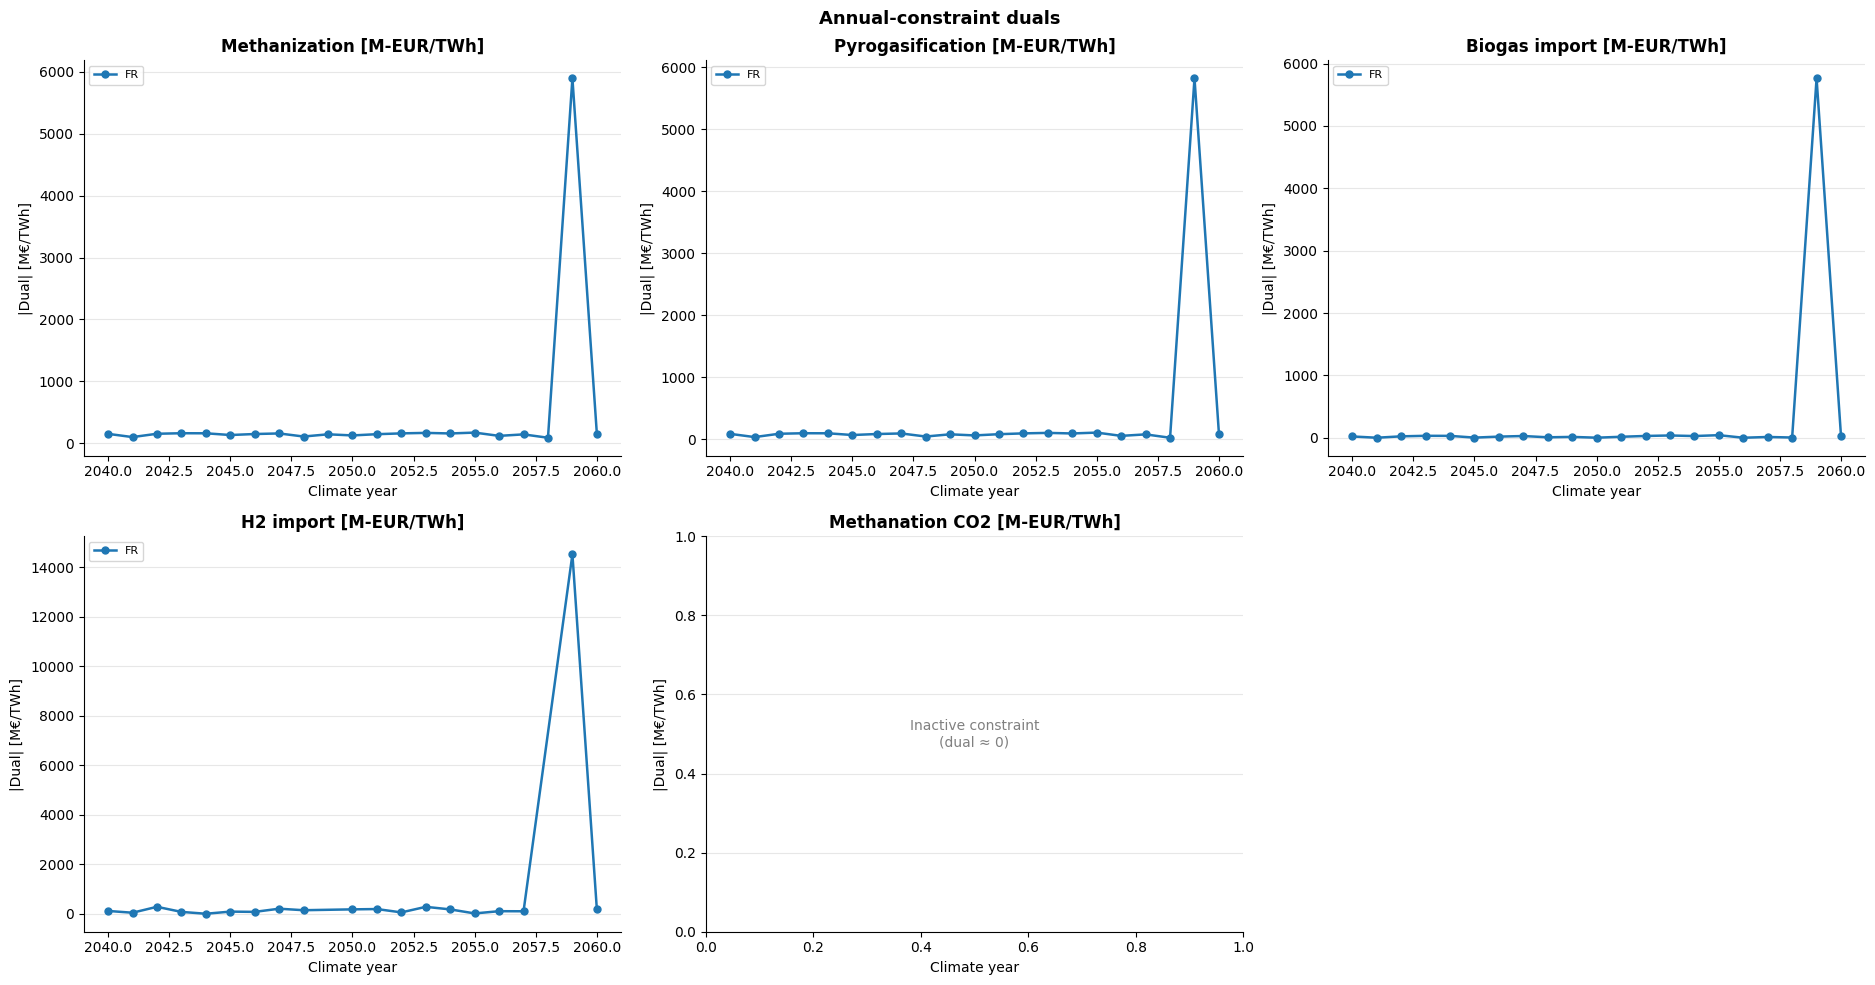

In [51]:
ANNUAL_DUALS = [
    ("annual_methanization", "Methanization [M-EUR/TWh]", True),
    ("annual_pyrogazification", "Pyrogasification [M-EUR/TWh]", True),
    ("annual_biogas_import", "Biogas import [M-EUR/TWh]", True),
    ("annual_H2_import", "H2 import [M-EUR/TWh]", True),
    ("methanation_CO2", "Methanation CO2 [M-EUR/TWh]", False),  # no area column (France-only constraint)
]
duals_by_constraint = {
    name: (ub.load_annual_dual(BATCH_DIR, first_scenario, YEARS, name), label, has_area)
    for name, label, has_area in ANNUAL_DUALS
}
fig = plot_annual_duals_timeseries(duals_by_constraint, areas=COUNTRIES, lang="EN")

---
## Comparer un autre pays

Toutes les fonctions ci-dessus (sections 1 a 6) prennent `AREA` en parametre - il suffit de changer sa valeur et de relancer les cellules pour la meme analyse sur un autre pays (ex. `AREA = "DE"`). Pas besoin de fonctions dediees par pays.

In [70]:
AREA = "UK"
SCENARIOS = {
    "FR interconnectee": "FR_interconnected",             # e.g. {"FR seule": "FR_alone", "FR interconnectee": "FR_interconnected"}
}

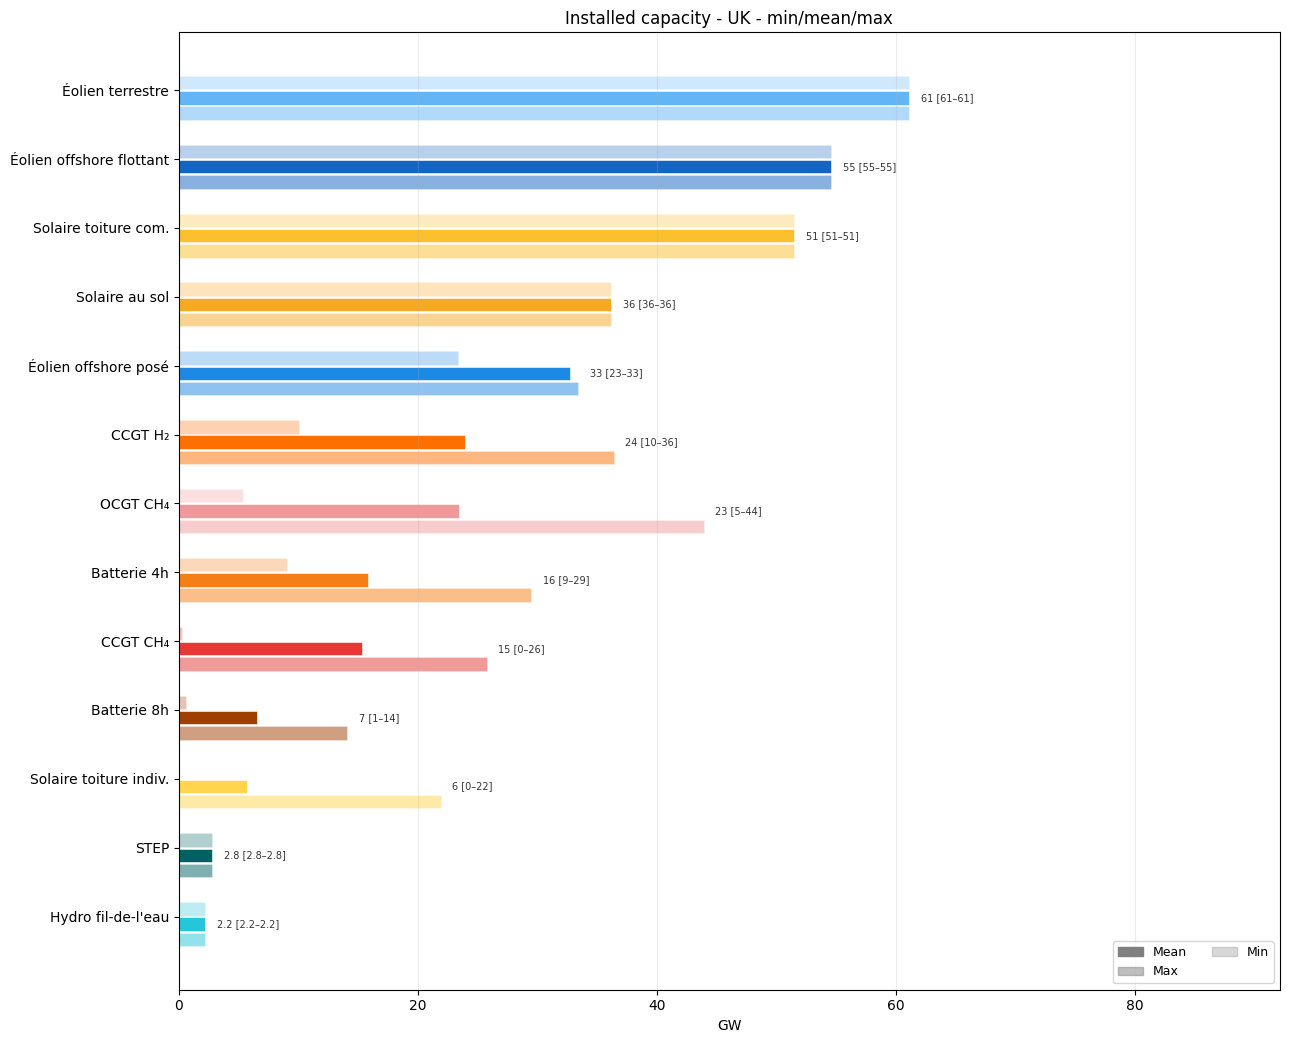

In [71]:
cap_data = {
    label: ub.load_across_years(BATCH_DIR, "installed_power_GW", scenario, YEARS, AREA)
    for label, scenario in SCENARIOS.items()
}
fig = plot_min_mean_max(cap_data, exclude = GENE_EXCLUDE, title=f"Installed capacity - {AREA} - min/mean/max", unit="GW")

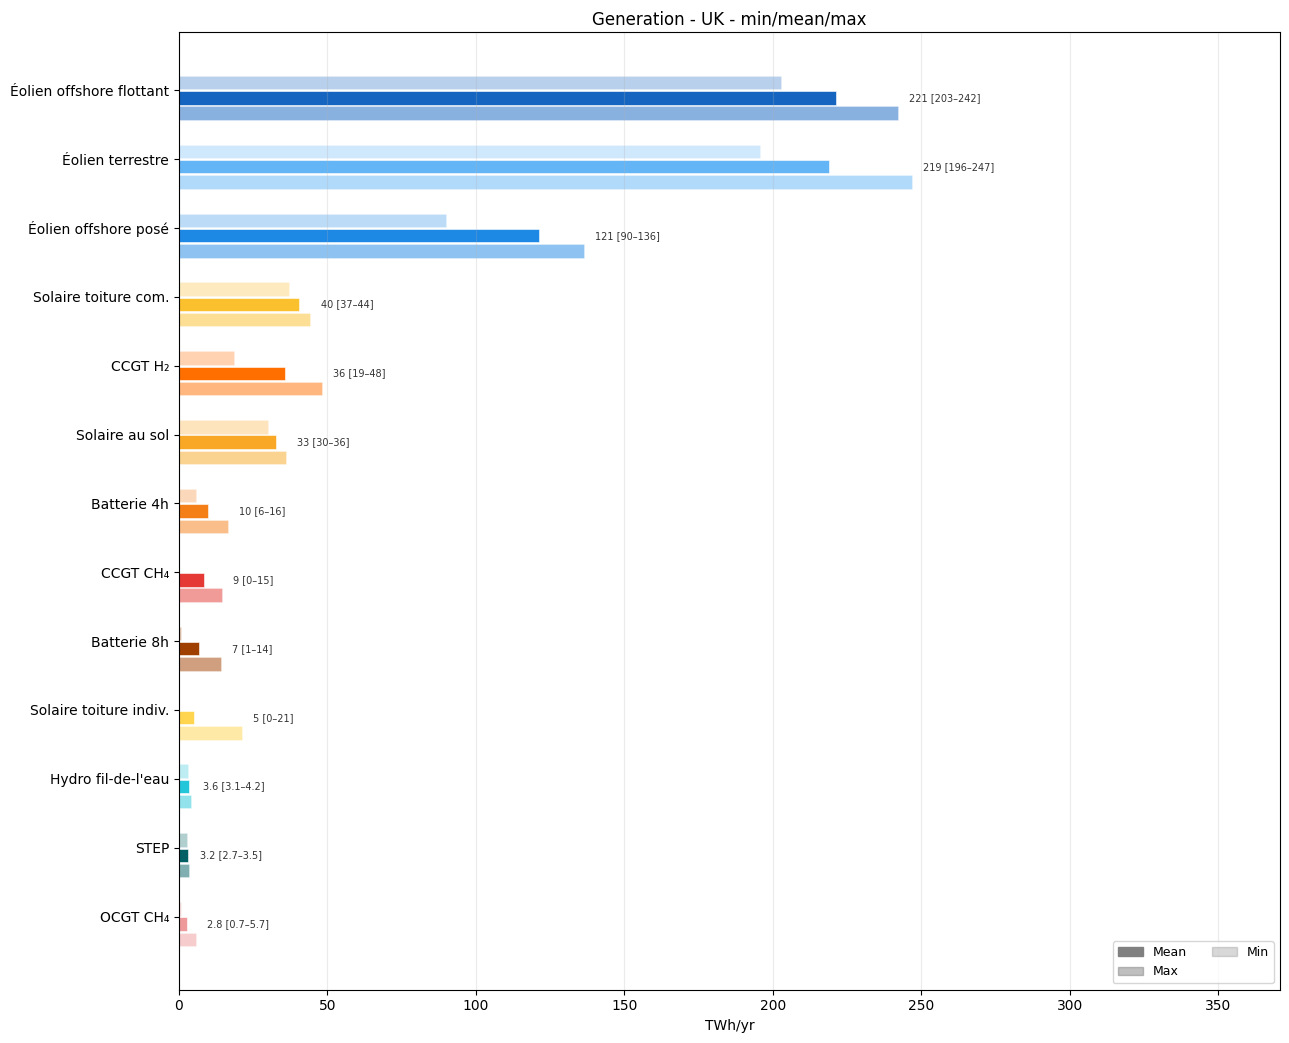

In [72]:
gene_data = {
    label: ub.load_across_years(BATCH_DIR, "generation_per_tech_TWh", scenario, YEARS, AREA)
    for label, scenario in SCENARIOS.items()
}
GENE_EXCLUDE = TECH_EXCLUDE_DEFAULT | {
    "ch4_reservoir", "methanization", "electrolysis",
    "h2_saltcavern", "pyrogazification", "methanation", "biogas_import",
}
fig = plot_min_mean_max(gene_data, title=f"Generation - {AREA} - min/mean/max", unit="TWh/yr",
                        min_val=0.05, exclude=GENE_EXCLUDE)